# Análise de Dados do E-commerce Brasileiro

Este notebook contém a análise completa do conjunto de dados da Olist, uma plataforma de e-commerce brasileira. O objetivo é extrair insights valiosos que possam ajudar nas decisões estratégicas do negócio.

## Estrutura do Projeto

O projeto está organizado nas seguintes seções:

1. Preparação dos Dados
2. Análise Exploratória de Dados
3. Solução de Problemas de Negócio
4. Visualização e Dashboards

Vou começar importando as bibliotecas necessárias e carregando os dados.

# Nova seção

In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings

# Configurações de visualização
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')
plt.style.use('fivethirtyeight')
%matplotlib inline

## 1. Preparação dos Dados

Nesta seção, faço a importação e leitura dos arquivos CSV, realizando  a limpeza necessária e criando um modelo relacional para conectar as tabelas adequadamente.

In [2]:
# Carregando os datasets
customers = pd.read_csv('olist_customers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

# Exibindo informações básicas sobre os datasets
print("Dimensões dos datasets:")
print(f"Customers: {customers.shape}")
print(f"Geolocation: {geolocation.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Order Payments: {order_payments.shape}")
print(f"Order Reviews: {order_reviews.shape}")
print(f"Orders: {orders.shape}")
print(f"Products: {products.shape}")
print(f"Sellers: {sellers.shape}")
print(f"Category Translation: {category_translation.shape}")

Dimensões dos datasets:
Customers: (99441, 5)
Geolocation: (1000163, 5)
Order Items: (112650, 7)
Order Payments: (103886, 5)
Order Reviews: (99224, 7)
Orders: (99441, 8)
Products: (32951, 9)
Sellers: (3095, 4)
Category Translation: (71, 2)


### 1.1 Verificação de Valores Nulos e Duplicados

Verificando  a presença de valores nulos e duplicados em cada dataset para entender melhor a qualidade dos dados.

In [3]:
# Função para verificar valores nulos em cada dataset
def check_nulls(dataframes_dict):
    for name, df in dataframes_dict.items():
        null_count = df.isnull().sum()
        if null_count.sum() > 0:
            print(f"\nValores nulos em {name}:")
            print(null_count[null_count > 0])
        else:
            print(f"\nNenhum valor nulo encontrado em {name}")

# Função para verificar duplicatas em cada dataset
def check_duplicates(dataframes_dict):
    for name, df in dataframes_dict.items():
        duplicates = df.duplicated().sum()
        print(f"\nDuplicatas em {name}: {duplicates}")

# Criando um dicionário com todos os dataframes
dataframes = {
    'customers': customers,
    'geolocation': geolocation,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

# Verificando valores nulos
check_nulls(dataframes)

# Verificando duplicatas
check_duplicates(dataframes)


Nenhum valor nulo encontrado em customers

Nenhum valor nulo encontrado em geolocation

Nenhum valor nulo encontrado em order_items

Nenhum valor nulo encontrado em order_payments

Valores nulos em order_reviews:
review_comment_title      87656
review_comment_message    58247
dtype: int64

Valores nulos em orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Valores nulos em products:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Nenhum valor nulo encontrado em sellers

Nenhum valor nulo encontrado em category_translation

Duplicatas em customers: 0

Duplicatas em geolocation: 261831

Duplicatas em order_items: 0

Duplicatas em order_payments: 0

Duplicatas em order_r

### 1.2 Limpeza e Tratamento dos Dados

Com base na análise anterior, vou realizar a limpeza e o tratamento necessários nos datasets.

In [4]:
# Tratando valores nulos nos produtos
products['product_category_name'] = products['product_category_name'].fillna('unknown')
products['product_name_lenght'] = products['product_name_lenght'].fillna(products['product_name_lenght'].median())
products['product_description_lenght'] = products['product_description_lenght'].fillna(products['product_description_lenght'].median())
products['product_photos_qty'] = products['product_photos_qty'].fillna(products['product_photos_qty'].median())
products['product_weight_g'] = products['product_weight_g'].fillna(products['product_weight_g'].median())
products['product_length_cm'] = products['product_length_cm'].fillna(products['product_length_cm'].median())
products['product_height_cm'] = products['product_height_cm'].fillna(products['product_height_cm'].median())
products['product_width_cm'] = products['product_width_cm'].fillna(products['product_width_cm'].median())

# Tratando valores nulos nos pedidos
# Alguns pedidos podem não ter sido aprovados, entregues à transportadora ou ao cliente
# Vou manter esses valores nulos, pois representam informações reais do processo

# Removendo duplicatas na geolocalização
geolocation = geolocation.drop_duplicates()

# Convertendo colunas de data para o formato datetime
date_columns = [
    'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# Convertendo colunas de data nas reviews
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

# Convertendo colunas de data nos itens do pedido
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

# Verificando os resultados após a limpeza
check_nulls(dataframes)


Nenhum valor nulo encontrado em customers

Nenhum valor nulo encontrado em geolocation

Nenhum valor nulo encontrado em order_items

Nenhum valor nulo encontrado em order_payments

Valores nulos em order_reviews:
review_comment_title      87656
review_comment_message    58247
dtype: int64

Valores nulos em orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Nenhum valor nulo encontrado em products

Nenhum valor nulo encontrado em sellers

Nenhum valor nulo encontrado em category_translation


### 1.3 Criação do Modelo Relacional
Criando o banco de dados SQLite para armazenar os dados e facilitar as consultas SQL. Isso  permitirá explorar as relações entre as tabelas de forma mais eficiente.

In [5]:
# Criando um banco de dados SQLite
conn = sqlite3.connect('olist.db')

# Salvando os dataframes como tabelas no banco de dados
customers.to_sql('customers', conn, if_exists='replace', index=False)
geolocation.to_sql('geolocation', conn, if_exists='replace', index=False)
order_items.to_sql('order_items', conn, if_exists='replace', index=False)
order_payments.to_sql('order_payments', conn, if_exists='replace', index=False)
order_reviews.to_sql('order_reviews', conn, if_exists='replace', index=False)
orders.to_sql('orders', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)
sellers.to_sql('sellers', conn, if_exists='replace', index=False)
category_translation.to_sql('category_translation', conn, if_exists='replace', index=False)

print("Banco de dados SQLite criado com sucesso!")

Banco de dados SQLite criado com sucesso!


### 1.4 Descrição do Modelo Relacional

Descrição do modelo relacional criado, identificando as chaves primárias e estrangeiras, bem como as relações entre as tabelas.

O modelo relacional do conjunto de dados da Olist pode ser descrito da seguinte forma:

1. **Customers (Clientes)**
   - Chave Primária: `customer_id`
   - Contém informações sobre os clientes, como localização (CEP, cidade, estado)
   - Relaciona-se com a tabela Orders através de `customer_id`

2. **Orders (Pedidos)**
   - Chave Primária: `order_id`
   - Chave Estrangeira: `customer_id` (referencia Customers)
   - Contém informações sobre os pedidos, como status, datas de compra, aprovação e entrega
   - Relaciona-se com Order Items, Order Payments e Order Reviews através de `order_id`

3. **Order Items (Itens do Pedido)**
   - Chaves Estrangeiras: `order_id` (referencia Orders), `product_id` (referencia Products), `seller_id` (referencia Sellers)
   - Contém informações sobre os itens de cada pedido, como preço e frete

4. **Order Payments (Pagamentos do Pedido)**
   - Chave Estrangeira: `order_id` (referencia Orders)
   - Contém informações sobre os pagamentos de cada pedido, como tipo, parcelas e valor

5. **Order Reviews (Avaliações do Pedido)**
   - Chave Primária: `review_id`
   - Chave Estrangeira: `order_id` (referencia Orders)
   - Contém informações sobre as avaliações de cada pedido, como nota e comentários

6. **Products (Produtos)**
   - Chave Primária: `product_id`
   - Contém informações sobre os produtos, como categoria, dimensões e peso
   - Relaciona-se com Order Items através de `product_id`
   - Relaciona-se com Category Translation através de `product_category_name`

7. **Sellers (Vendedores)**
   - Chave Primária: `seller_id`
   - Contém informações sobre os vendedores, como localização (CEP, cidade, estado)
   - Relaciona-se com Order Items através de `seller_id`

8. **Geolocation (Geolocalização)**
   - Contém informações de geolocalização para os CEPs brasileiros
   - Pode ser relacionada com Customers e Sellers através do prefixo do CEP

9. **Category Translation (Tradução de Categorias)**
   - Contém a tradução das categorias de produtos do português para o inglês
   - Relaciona-se com Products através de `product_category_name`

## 2. Análise Exploratória de Dados

Nesta seção, vou responder às perguntas específicas do desafio utilizando SQL e Python.

### 2.1 Volume de Pedidos por Mês e Sazonalidade

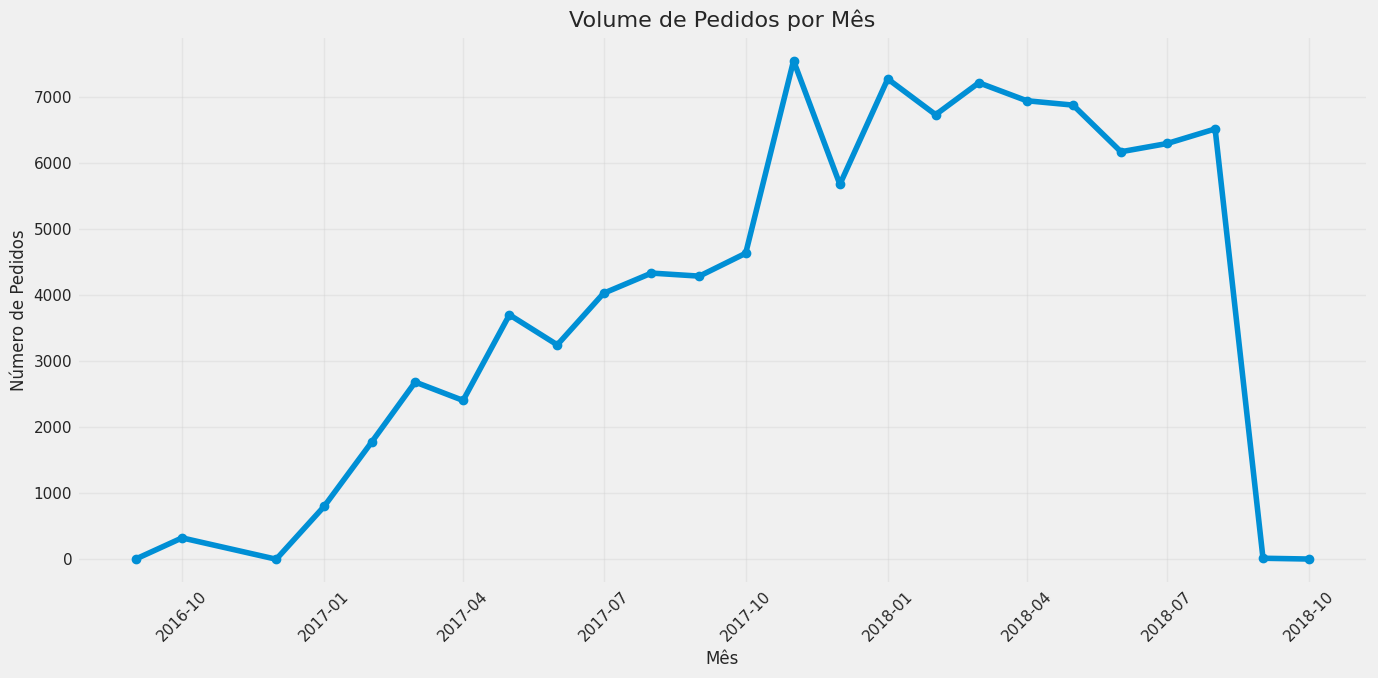

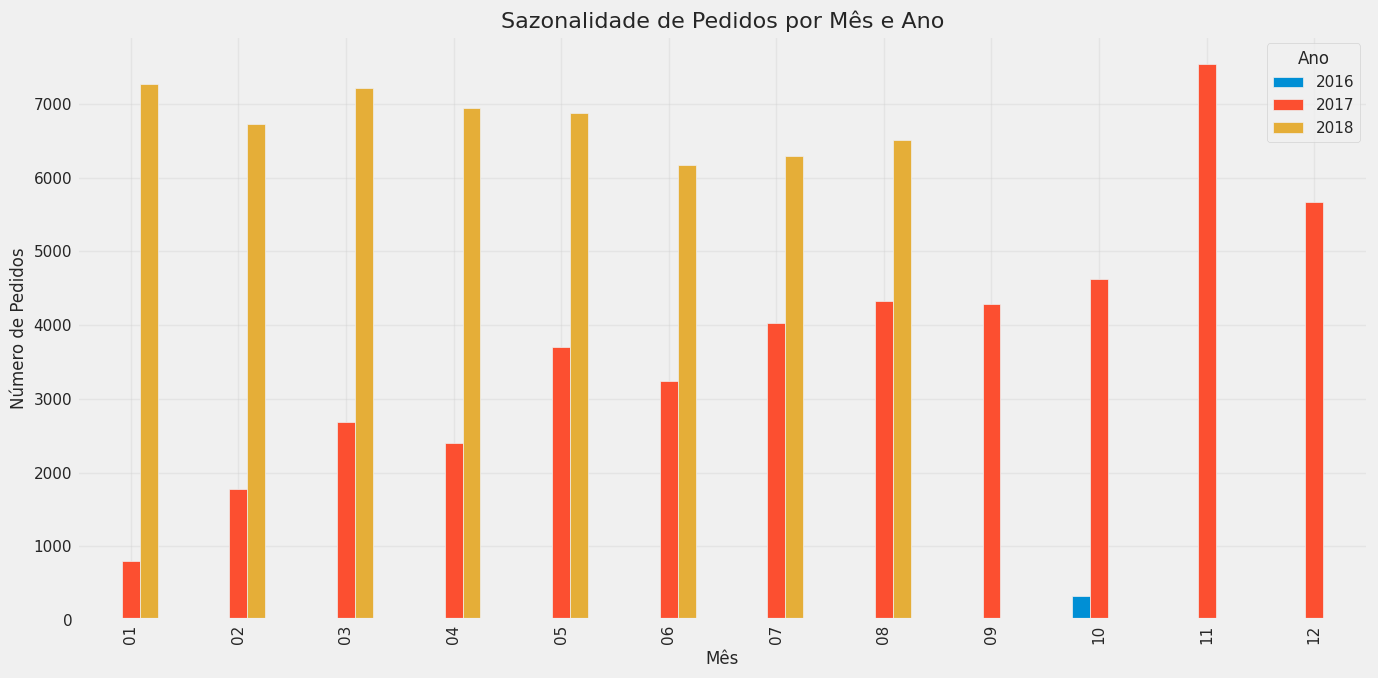

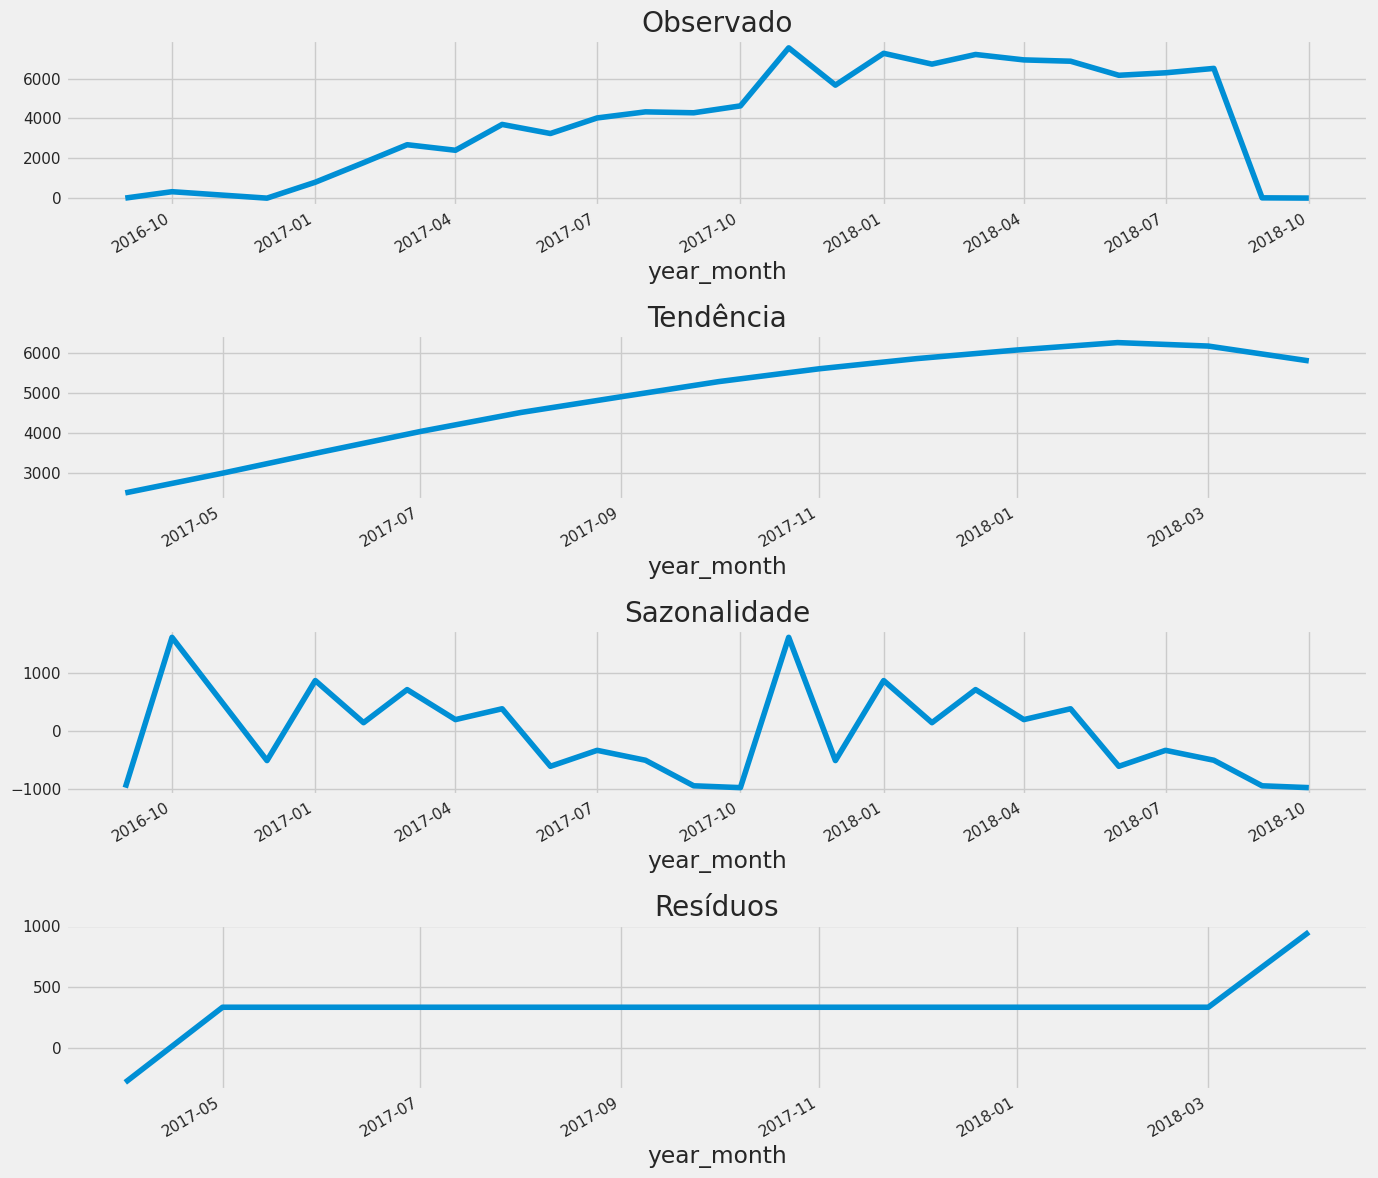

In [6]:
# Consultando o volume de pedidos por mês usando SQL
query = """
SELECT
    strftime('%Y-%m', order_purchase_timestamp) as year_month,
    COUNT(*) as order_count
FROM
    orders
GROUP BY
    year_month
ORDER BY
    year_month
"""

orders_per_month = pd.read_sql_query(query, conn)

# Convertendo a coluna year_month para datetime para melhor visualização
orders_per_month['year_month'] = pd.to_datetime(orders_per_month['year_month'] + '-01')

# Plotando o gráfico de volume de pedidos por mês
plt.figure(figsize=(14, 7))
plt.plot(orders_per_month['year_month'], orders_per_month['order_count'], marker='o', linestyle='-')
plt.title('Volume de Pedidos por Mês', fontsize=16)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Número de Pedidos', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analisando a sazonalidade por mês do ano
query_seasonality = """
SELECT
    strftime('%m', order_purchase_timestamp) as month,
    strftime('%Y', order_purchase_timestamp) as year,
    COUNT(*) as order_count
FROM
    orders
GROUP BY
    year, month
ORDER BY
    year, month
"""

seasonality_data = pd.read_sql_query(query_seasonality, conn)

# Criando um pivot table para visualizar a sazonalidade
seasonality_pivot = seasonality_data.pivot(index='month', columns='year', values='order_count')

# Plotando o gráfico de sazonalidade
plt.figure(figsize=(14, 7))
seasonality_pivot.plot(kind='bar', ax=plt.gca())
plt.title('Sazonalidade de Pedidos por Mês e Ano', fontsize=16)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Número de Pedidos', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Ano')
plt.tight_layout()
plt.show()

# Análise de sazonalidade usando decomposição de séries temporais
from statsmodels.tsa.seasonal import seasonal_decompose

# Preparando os dados para decomposição
orders_per_month.set_index('year_month', inplace=True)
orders_ts = orders_per_month['order_count']

# Realizando a decomposição
decomposition = seasonal_decompose(orders_ts, model='additive', period=12)

# Plotando os resultados da decomposição
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 12))
decomposition.observed.plot(ax=ax1)
ax1.set_title('Observado')
decomposition.trend.plot(ax=ax2)
ax2.set_title('Tendência')
decomposition.seasonal.plot(ax=ax3)
ax3.set_title('Sazonalidade')
decomposition.resid.plot(ax=ax4)
ax4.set_title('Resíduos')
plt.tight_layout()
plt.show()

### 2.2 Distribuição do Tempo de Entrega dos Pedidos

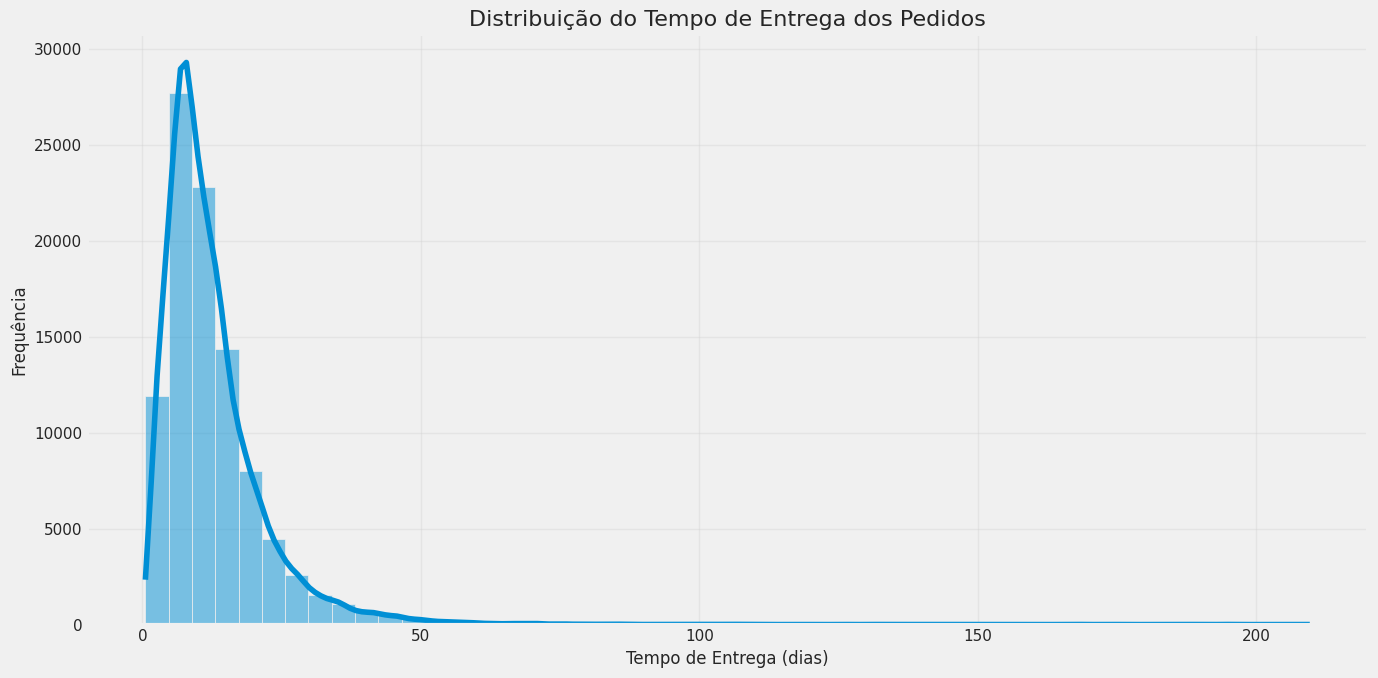

Estatísticas do Tempo de Entrega (em dias):
count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_time_days, dtype: float64


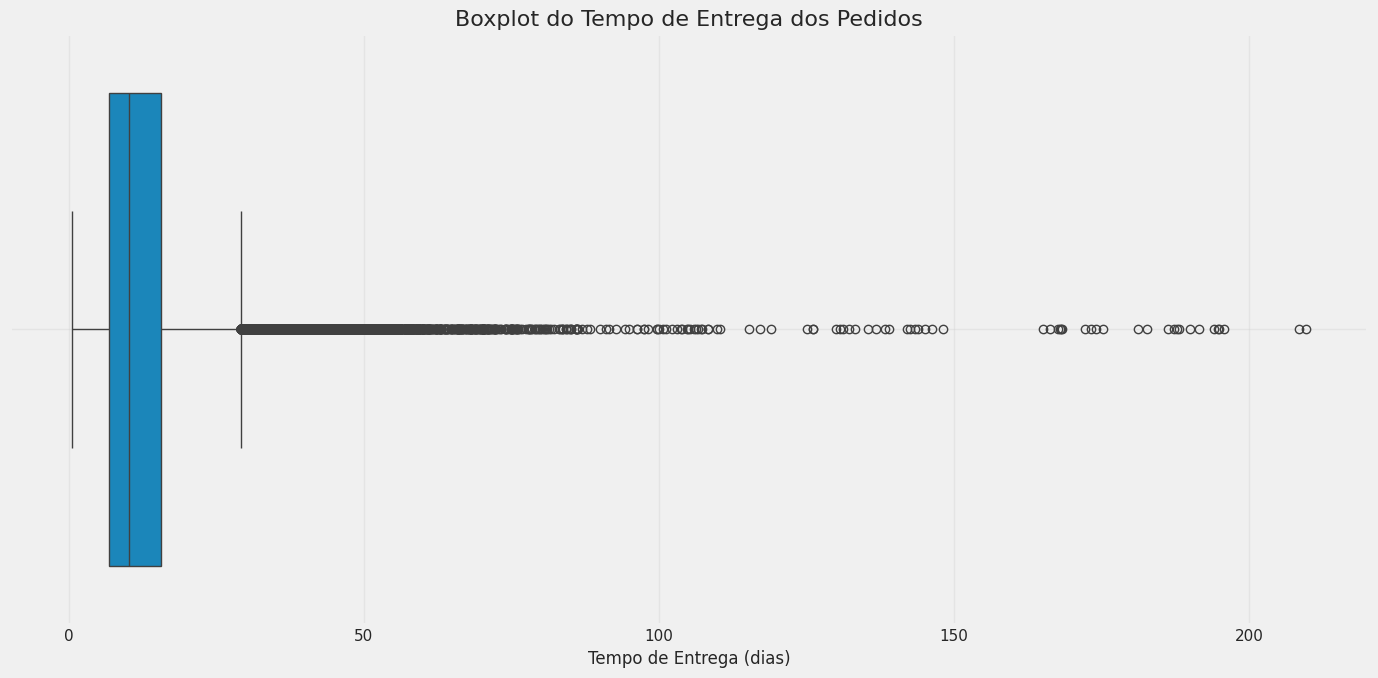

In [7]:
# Consultando o tempo de entrega dos pedidos usando SQL
query = """
SELECT
    julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp) as delivery_time_days
FROM
    orders
WHERE
    order_delivered_customer_date IS NOT NULL
"""

delivery_time = pd.read_sql_query(query, conn)

# Plotando a distribuição do tempo de entrega
plt.figure(figsize=(14, 7))
sns.histplot(delivery_time['delivery_time_days'], bins=50, kde=True)
plt.title('Distribuição do Tempo de Entrega dos Pedidos', fontsize=16)
plt.xlabel('Tempo de Entrega (dias)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estatísticas descritivas do tempo de entrega
delivery_stats = delivery_time['delivery_time_days'].describe()
print("Estatísticas do Tempo de Entrega (em dias):")
print(delivery_stats)

# Boxplot do tempo de entrega
plt.figure(figsize=(14, 7))
sns.boxplot(x=delivery_time['delivery_time_days'])
plt.title('Boxplot do Tempo de Entrega dos Pedidos', fontsize=16)
plt.xlabel('Tempo de Entrega (dias)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3 Relação entre o Valor do Frete e a Distância de Entrega

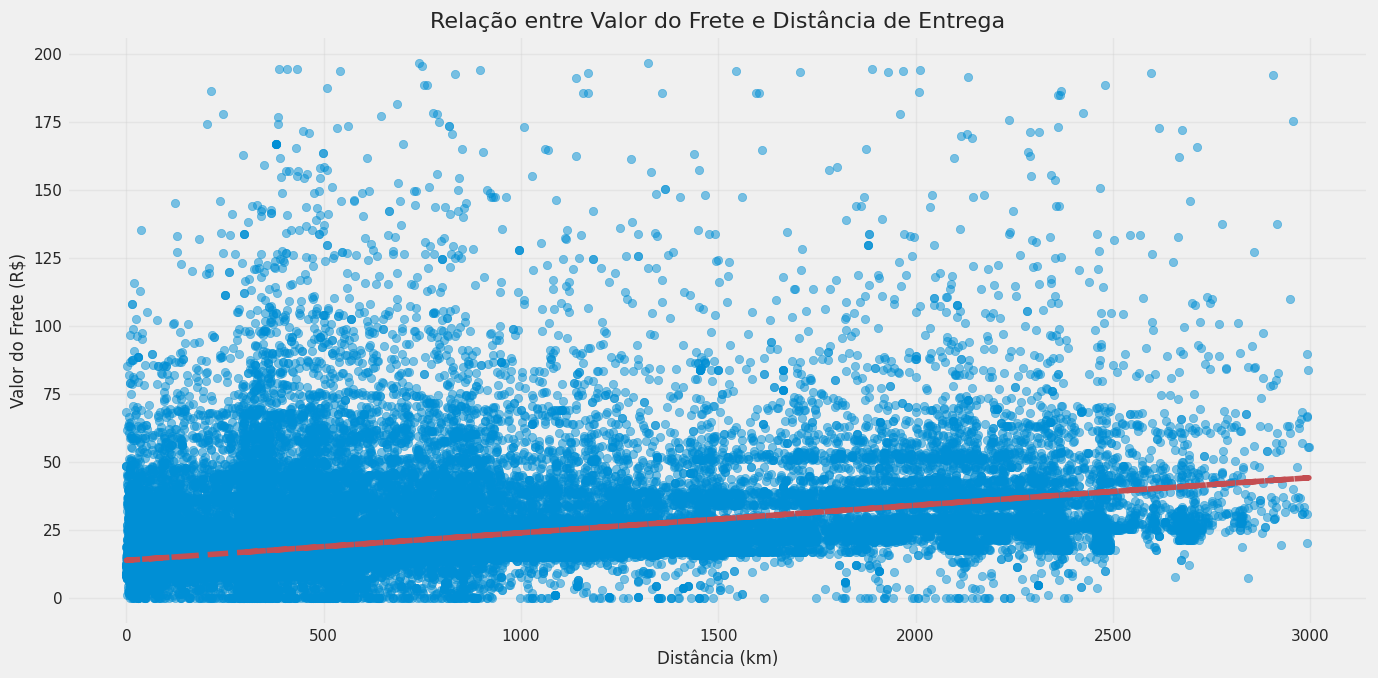

Correlação entre Valor do Frete e Distância: 0.4042


In [8]:
# Primeiro, vamos calcular a distância entre o vendedor e o cliente
# Para isso, precisamos juntar as tabelas de clientes, pedidos, itens do pedido, vendedores e geolocalização

# Função para calcular a distância entre dois pontos usando a fórmula de Haversine
def haversine_distance(lat1, lon1, lat2, lon2):
    # Convertendo graus para radianos
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Fórmula de Haversine
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Raio da Terra em quilômetros
    return c * r

# Consultando os dados necessários para calcular a distância
query = """
SELECT
    oi.order_id,
    oi.freight_value,
    c.customer_zip_code_prefix,
    s.seller_zip_code_prefix
FROM
    order_items oi
JOIN
    orders o ON oi.order_id = o.order_id
JOIN
    customers c ON o.customer_id = c.customer_id
JOIN
    sellers s ON oi.seller_id = s.seller_id
"""

freight_data = pd.read_sql_query(query, conn)

# Agora, vamos obter as coordenadas de geolocalização para os CEPs dos clientes e vendedores
# Para simplificar, vamos usar a média das coordenadas para cada CEP
customer_geo = geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

seller_geo = geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# Renomeando as colunas para facilitar o merge
customer_geo.columns = ['customer_zip_code_prefix', 'customer_lat', 'customer_lng']
seller_geo.columns = ['seller_zip_code_prefix', 'seller_lat', 'seller_lng']

# Convertendo os tipos de dados para garantir o merge correto
freight_data['customer_zip_code_prefix'] = freight_data['customer_zip_code_prefix'].astype(str)
freight_data['seller_zip_code_prefix'] = freight_data['seller_zip_code_prefix'].astype(str)
customer_geo['customer_zip_code_prefix'] = customer_geo['customer_zip_code_prefix'].astype(str)
seller_geo['seller_zip_code_prefix'] = seller_geo['seller_zip_code_prefix'].astype(str)

# Fazendo o merge com as coordenadas
freight_data = freight_data.merge(customer_geo, on='customer_zip_code_prefix', how='left')
freight_data = freight_data.merge(seller_geo, on='seller_zip_code_prefix', how='left')

# Calculando a distância entre o cliente e o vendedor
freight_data['distance_km'] = freight_data.apply(
    lambda row: haversine_distance(
        row['customer_lat'], row['customer_lng'],
        row['seller_lat'], row['seller_lng']
    ) if pd.notna(row['customer_lat']) and pd.notna(row['seller_lat']) else np.nan,
    axis=1
)

# Removendo outliers para melhor visualização
freight_data = freight_data[(freight_data['distance_km'] < 3000) & (freight_data['freight_value'] < 200)]

# Plotando a relação entre o valor do frete e a distância
plt.figure(figsize=(14, 7))
plt.scatter(freight_data['distance_km'], freight_data['freight_value'], alpha=0.5)
plt.title('Relação entre Valor do Frete e Distância de Entrega', fontsize=16)
plt.xlabel('Distância (km)', fontsize=12)
plt.ylabel('Valor do Frete (R$)', fontsize=12)
plt.grid(True, alpha=0.3)

# Adicionando linha de tendência
z = np.polyfit(freight_data['distance_km'].dropna(), freight_data['freight_value'].dropna(), 1)
p = np.poly1d(z)
plt.plot(freight_data['distance_km'].dropna(), p(freight_data['distance_km'].dropna()), "r--")

plt.tight_layout()
plt.show()

# Calculando a correlação entre o valor do frete e a distância
correlation = freight_data['distance_km'].corr(freight_data['freight_value'])
print(f"Correlação entre Valor do Frete e Distância: {correlation:.4f}")

### 2.4 Categorias de Produtos Mais Vendidas em Termos de Faturamento

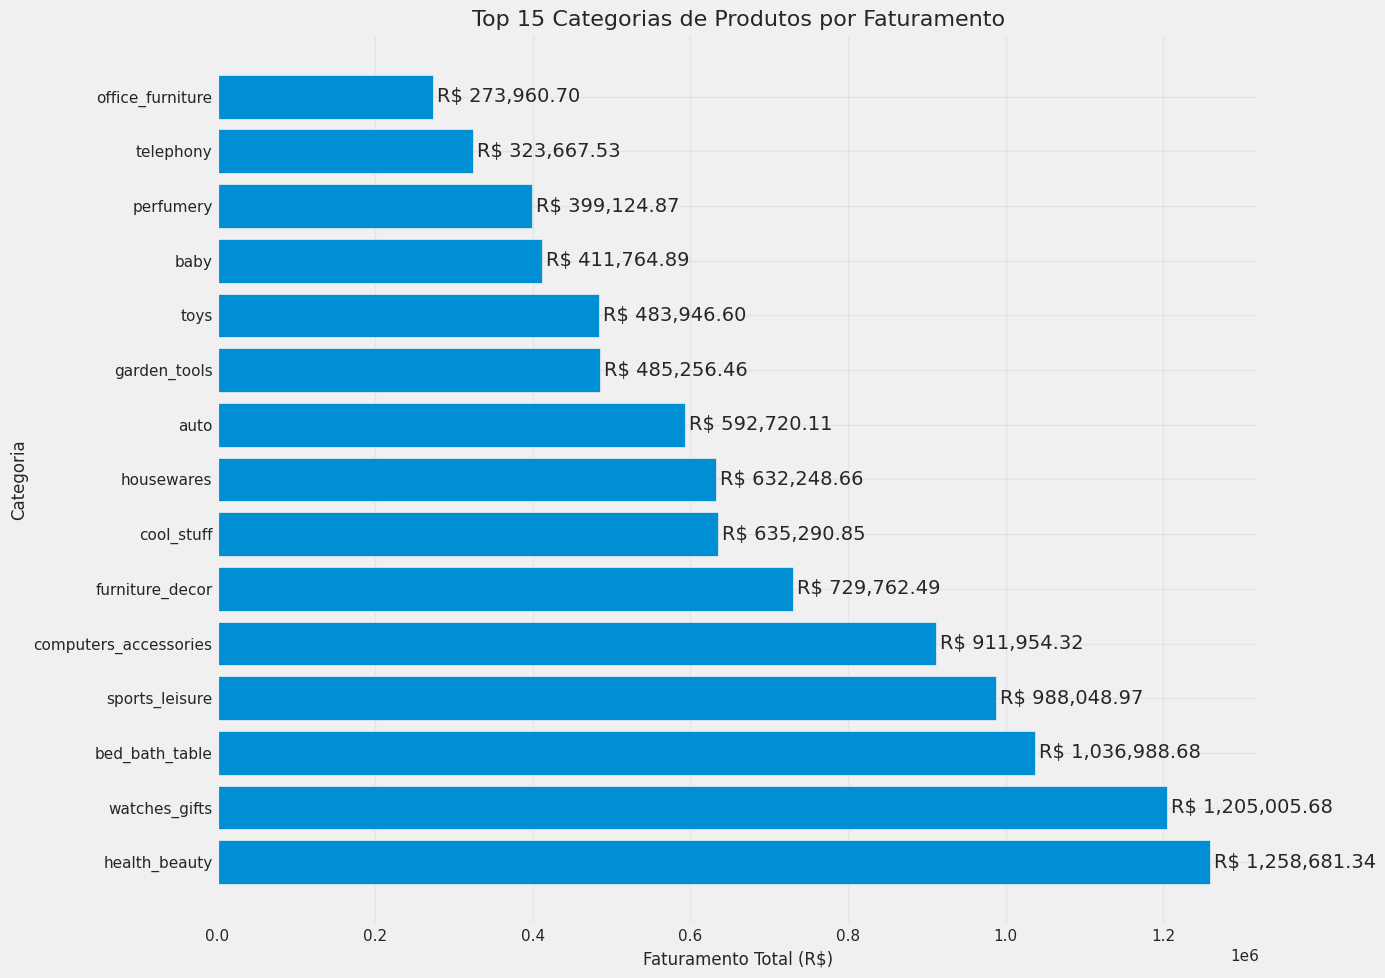

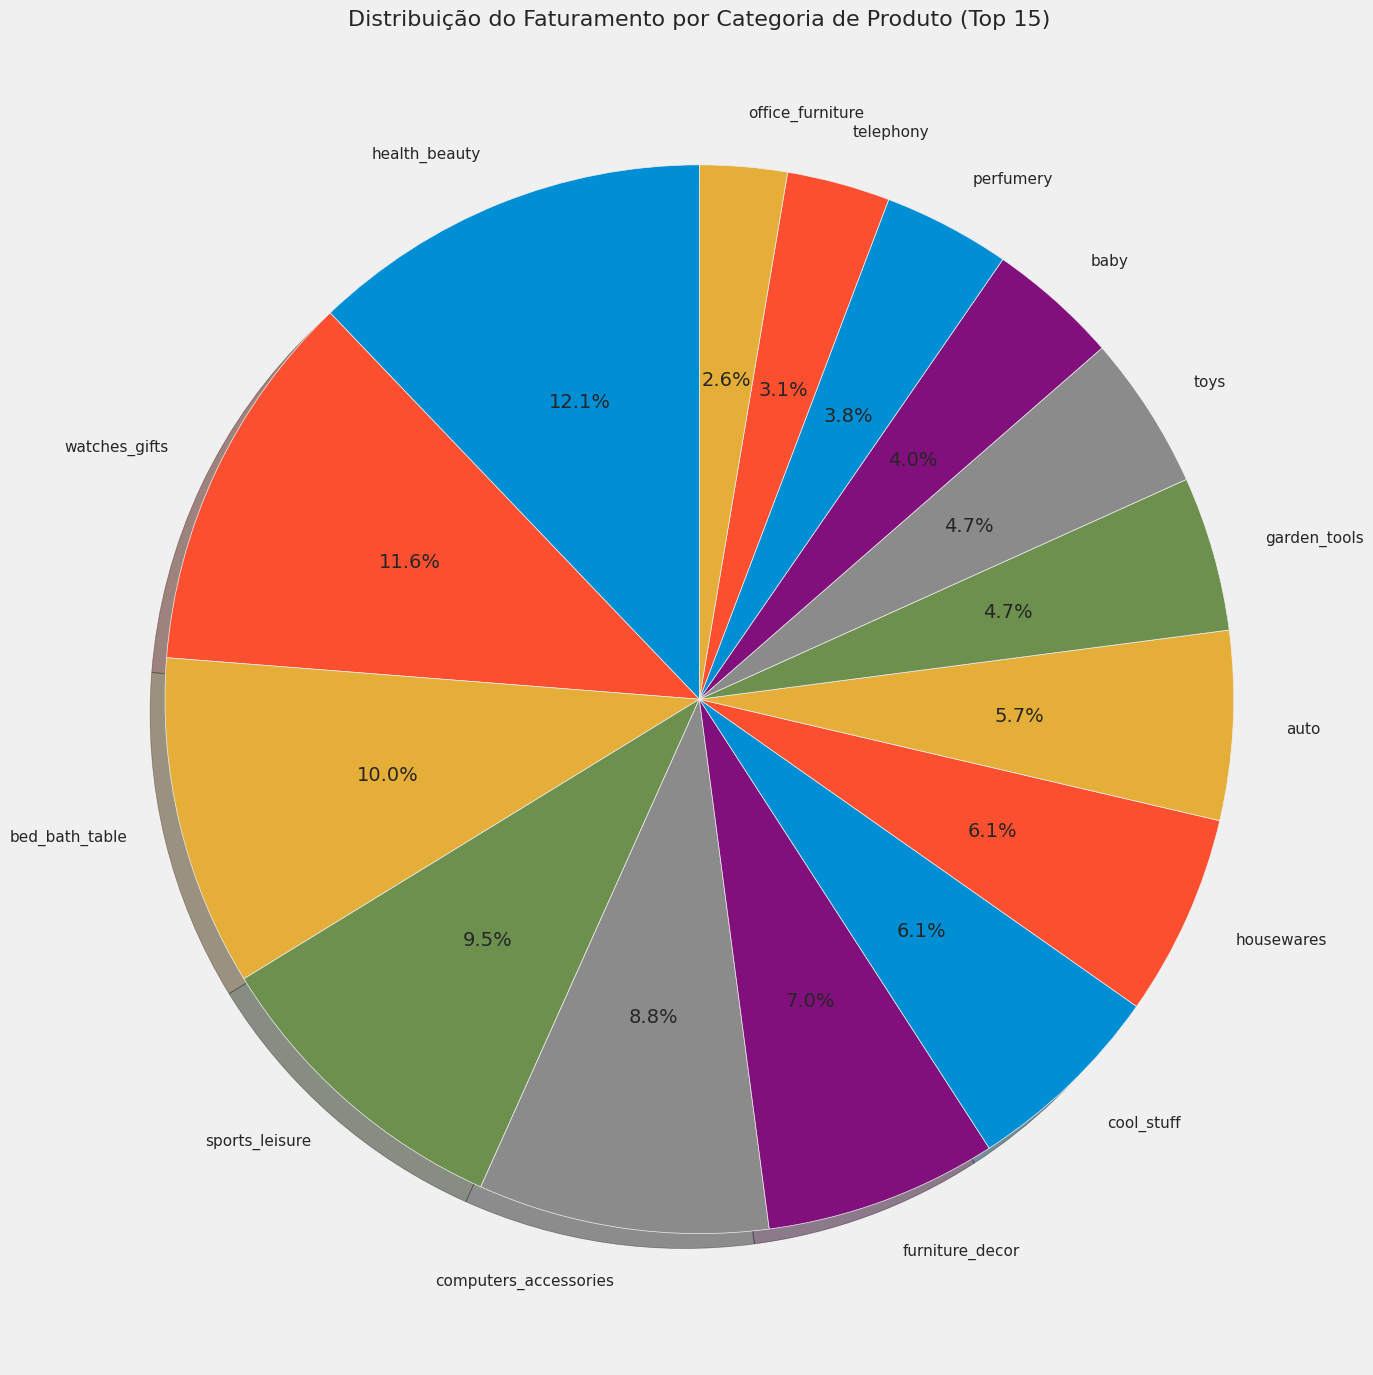

In [9]:
# Consultando as categorias de produtos mais vendidas em termos de faturamento
query = """
SELECT
    p.product_category_name,
    ct.product_category_name_english,
    COUNT(oi.order_id) as order_count,
    SUM(oi.price) as total_revenue
FROM
    order_items oi
JOIN
    products p ON oi.product_id = p.product_id
LEFT JOIN
    category_translation ct ON p.product_category_name = ct.product_category_name
GROUP BY
    p.product_category_name, ct.product_category_name_english
ORDER BY
    total_revenue DESC
"""

category_revenue = pd.read_sql_query(query, conn)

# Preenchendo categorias sem tradução
category_revenue['product_category_name_english'] = category_revenue['product_category_name_english'].fillna(category_revenue['product_category_name'])

# Pegando as top 15 categorias para visualização
top_categories = category_revenue.head(15)

# Plotando as categorias mais vendidas em termos de faturamento
plt.figure(figsize=(14, 10))
bars = plt.barh(top_categories['product_category_name_english'], top_categories['total_revenue'])
plt.title('Top 15 Categorias de Produtos por Faturamento', fontsize=16)
plt.xlabel('Faturamento Total (R$)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)
plt.grid(True, alpha=0.3)

# Adicionando os valores no final das barras
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             f'R$ {top_categories.iloc[i]["total_revenue"]:,.2f}',
             va='center')

plt.tight_layout()
plt.show()

# Criando um gráfico de pizza para visualizar a distribuição percentual
plt.figure(figsize=(14, 14))
plt.pie(top_categories['total_revenue'], labels=top_categories['product_category_name_english'],
        autopct='%1.1f%%', startangle=90, shadow=True)
plt.axis('equal')
plt.title('Distribuição do Faturamento por Categoria de Produto (Top 15)', fontsize=16)
plt.tight_layout()
plt.show()

### 2.5 Estados Brasileiros com o Maior Valor Médio de Pedido

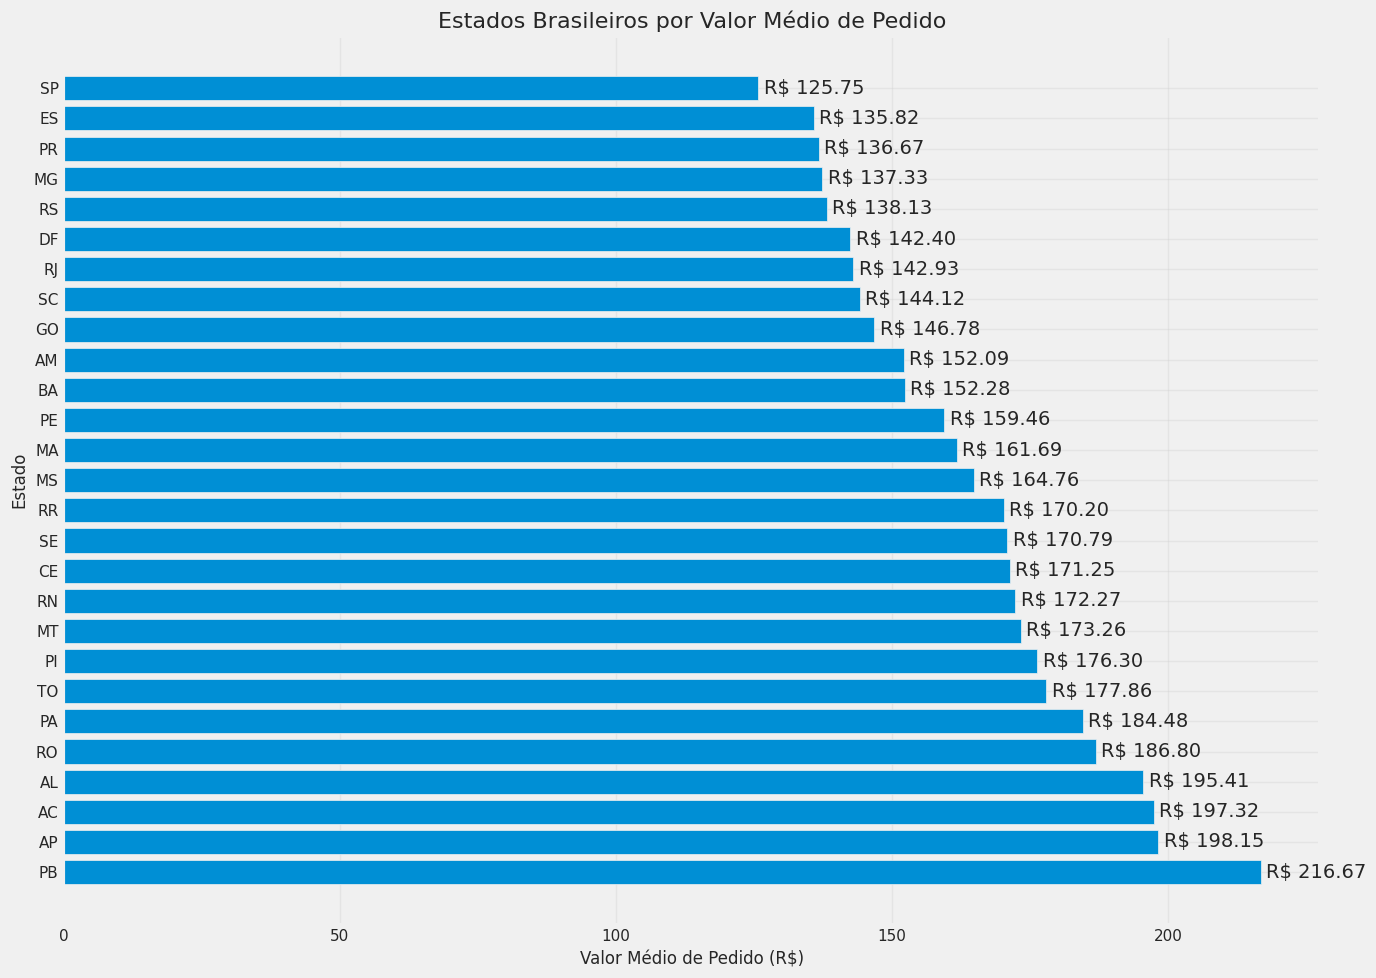

In [10]:
# Consultando os estados com o maior valor médio de pedido
query = """
SELECT
    c.customer_state,
    COUNT(DISTINCT o.order_id) as order_count,
    SUM(oi.price) as total_revenue,
    SUM(oi.price) / COUNT(DISTINCT o.order_id) as avg_order_value
FROM
    orders o
JOIN
    customers c ON o.customer_id = c.customer_id
JOIN
    order_items oi ON o.order_id = oi.order_id
GROUP BY
    c.customer_state
ORDER BY
    avg_order_value DESC
"""

state_avg_order = pd.read_sql_query(query, conn)

# Plotando os estados com o maior valor médio de pedido
plt.figure(figsize=(14, 10))
bars = plt.barh(state_avg_order['customer_state'], state_avg_order['avg_order_value'])
plt.title('Estados Brasileiros por Valor Médio de Pedido', fontsize=16)
plt.xlabel('Valor Médio de Pedido (R$)', fontsize=12)
plt.ylabel('Estado', fontsize=12)
plt.grid(True, alpha=0.3)

# Adicionando os valores no final das barras
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'R$ {state_avg_order.iloc[i]["avg_order_value"]:,.2f}',
             va='center')

plt.tight_layout()
plt.show()

# Criando um mapa de calor para visualizar o valor médio de pedido por estado
# Primeiro, precisamos de um dataframe com os códigos dos estados
state_codes = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas', 'BA': 'Bahia',
    'CE': 'Ceará', 'DF': 'Distrito Federal', 'ES': 'Espírito Santo', 'GO': 'Goiás',
    'MA': 'Maranhão', 'MT': 'Mato Grosso', 'MS': 'Mato Grosso do Sul', 'MG': 'Minas Gerais',
    'PA': 'Pará', 'PB': 'Paraíba', 'PR': 'Paraná', 'PE': 'Pernambuco', 'PI': 'Piauí',
    'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte', 'RS': 'Rio Grande do Sul',
    'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina', 'SP': 'São Paulo',
    'SE': 'Sergipe', 'TO': 'Tocantins'
}

# Criando um dataframe com os nomes completos dos estados
state_avg_order['state_name'] = state_avg_order['customer_state'].map(state_codes)

# Criando o mapa de calor usando Plotly
fig = px.choropleth(
    state_avg_order,
    locations='customer_state',
    locationmode='ISO-3',
    color='avg_order_value',
    hover_name='state_name',
    hover_data=['order_count', 'total_revenue', 'avg_order_value'],
    color_continuous_scale='Viridis',
    scope='south america',
    title='Valor Médio de Pedido por Estado Brasileiro'
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(height=600, margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

## 3. Solução de Problemas de Negócio

Nesta seção, vou resolver as questões de negócio propostas no desafio.

### 3.1 Análise de Retenção: Taxa de Clientes Recorrentes

Total de clientes: 96096
Clientes recorrentes: 2997
Taxa de retenção: 3.12%


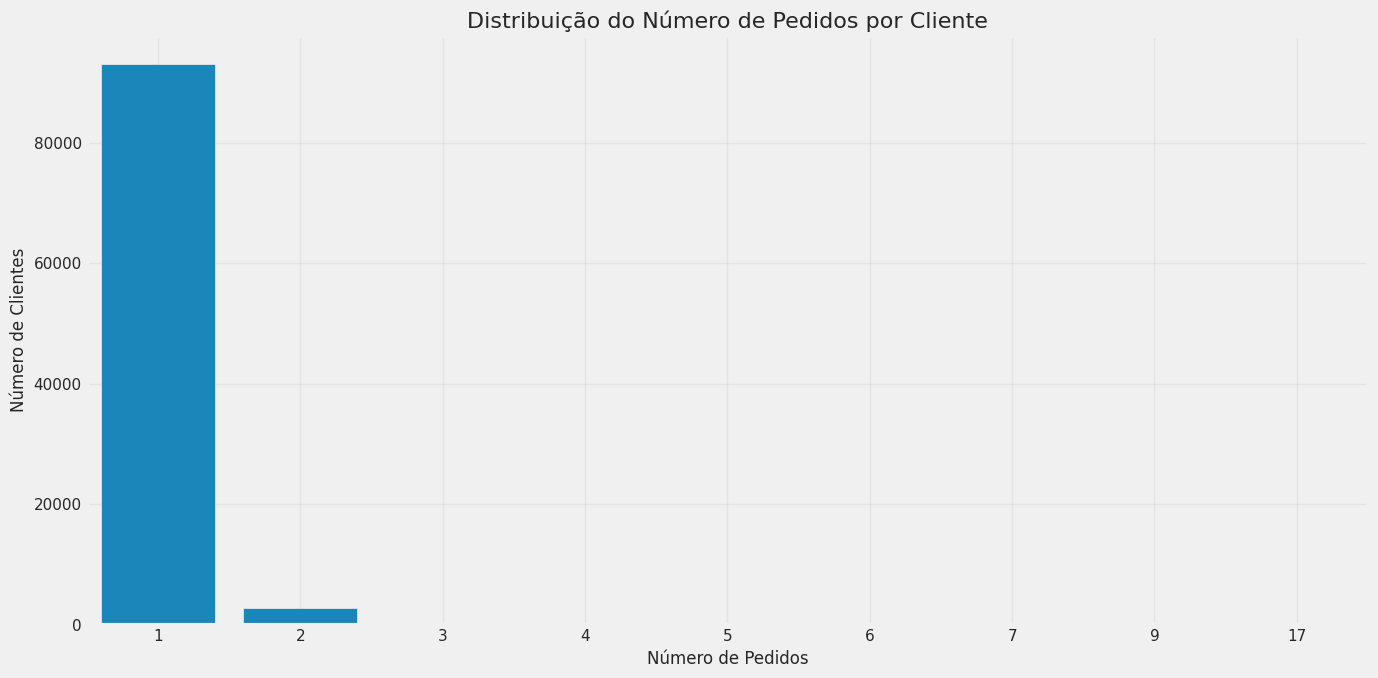

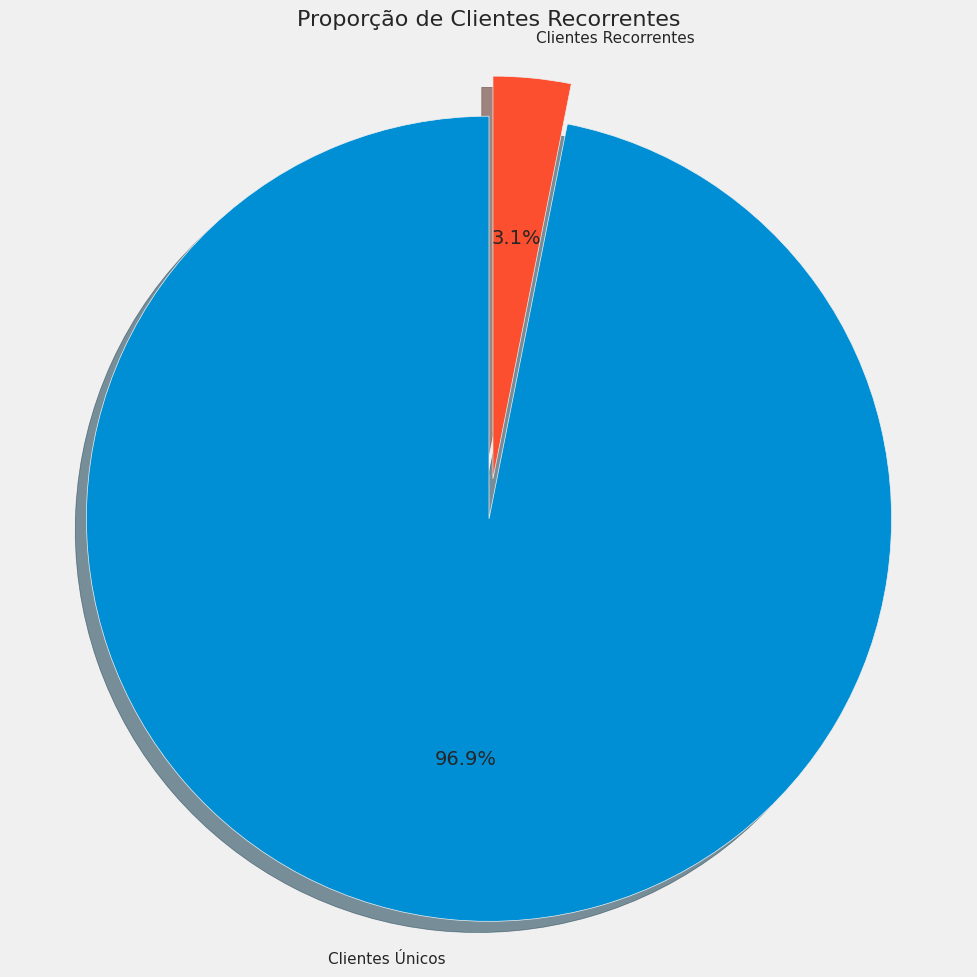

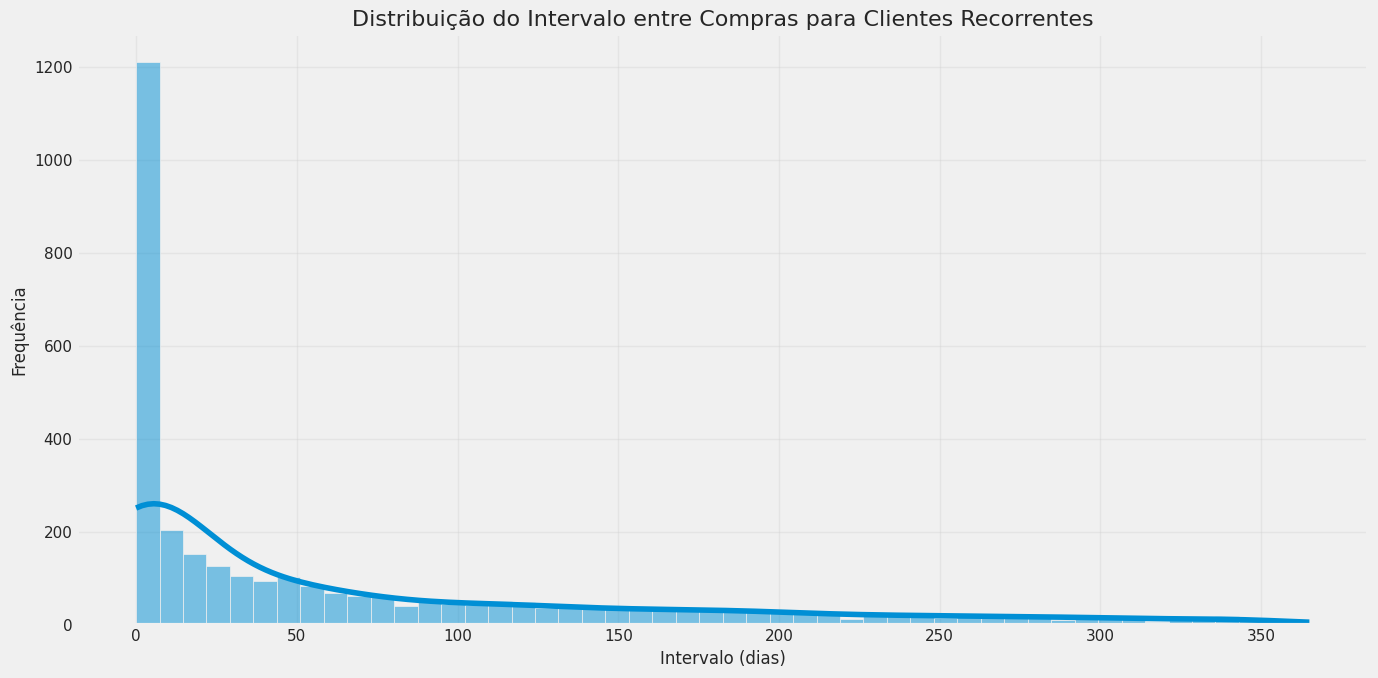

Estatísticas do Intervalo entre Compras (em dias):
count    3255.000000
mean       68.284883
std        90.103559
min         0.000000
25%         0.003108
50%        25.523160
75%       108.986678
max       364.975683
Name: days_between_orders, dtype: float64


In [11]:
# Consultando os clientes e seus pedidos
query = """
SELECT
    c.customer_unique_id,
    COUNT(o.order_id) as order_count
FROM
    customers c
JOIN
    orders o ON c.customer_id = o.customer_id
GROUP BY
    c.customer_unique_id
"""

customer_orders = pd.read_sql_query(query, conn)

# Calculando a taxa de clientes recorrentes
total_customers = len(customer_orders)
recurring_customers = len(customer_orders[customer_orders['order_count'] > 1])
retention_rate = recurring_customers / total_customers * 100

print(f"Total de clientes: {total_customers}")
print(f"Clientes recorrentes: {recurring_customers}")
print(f"Taxa de retenção: {retention_rate:.2f}%")

# Visualizando a distribuição do número de pedidos por cliente
plt.figure(figsize=(14, 7))
sns.countplot(x='order_count', data=customer_orders)
plt.title('Distribuição do Número de Pedidos por Cliente', fontsize=16)
plt.xlabel('Número de Pedidos', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Criando um gráfico de pizza para visualizar a proporção de clientes recorrentes
plt.figure(figsize=(10, 10))
plt.pie([total_customers - recurring_customers, recurring_customers],
        labels=['Clientes Únicos', 'Clientes Recorrentes'],
        autopct='%1.1f%%', startangle=90, shadow=True, explode=(0, 0.1))
plt.axis('equal')
plt.title('Proporção de Clientes Recorrentes', fontsize=16)
plt.tight_layout()
plt.show()

# Analisando o intervalo entre compras para clientes recorrentes
query_repurchase = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_purchase_timestamp,
        ROW_NUMBER() OVER (PARTITION BY c.customer_unique_id ORDER BY o.order_purchase_timestamp) as order_seq
    FROM
        customers c
    JOIN
        orders o ON c.customer_id = o.customer_id
)

SELECT
    co1.customer_unique_id,
    julianday(co2.order_purchase_timestamp) - julianday(co1.order_purchase_timestamp) as days_between_orders
FROM
    customer_orders co1
JOIN
    customer_orders co2 ON co1.customer_unique_id = co2.customer_unique_id AND co1.order_seq = co2.order_seq - 1
"""

repurchase_intervals = pd.read_sql_query(query_repurchase, conn)

# Removendo outliers para melhor visualização
repurchase_intervals = repurchase_intervals[repurchase_intervals['days_between_orders'] < 365]

# Visualizando a distribuição do intervalo entre compras
plt.figure(figsize=(14, 7))
sns.histplot(repurchase_intervals['days_between_orders'], bins=50, kde=True)
plt.title('Distribuição do Intervalo entre Compras para Clientes Recorrentes', fontsize=16)
plt.xlabel('Intervalo (dias)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estatísticas descritivas do intervalo entre compras
repurchase_stats = repurchase_intervals['days_between_orders'].describe()
print("Estatísticas do Intervalo entre Compras (em dias):")
print(repurchase_stats)

### 3.2 Predição de Atraso: Modelo para Prever se um Pedido Será Entregue com Atraso

Distribuição de pedidos atrasados:
is_delayed
0    88635
1     7826
Name: count, dtype: int64
Percentual de pedidos atrasados: 8.11%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     26630
           1       0.83      0.12      0.21      2309

    accuracy                           0.93     28939
   macro avg       0.88      0.56      0.58     28939
weighted avg       0.92      0.93      0.90     28939


Matriz de Confusão:
[[26574    56]
 [ 2037   272]]


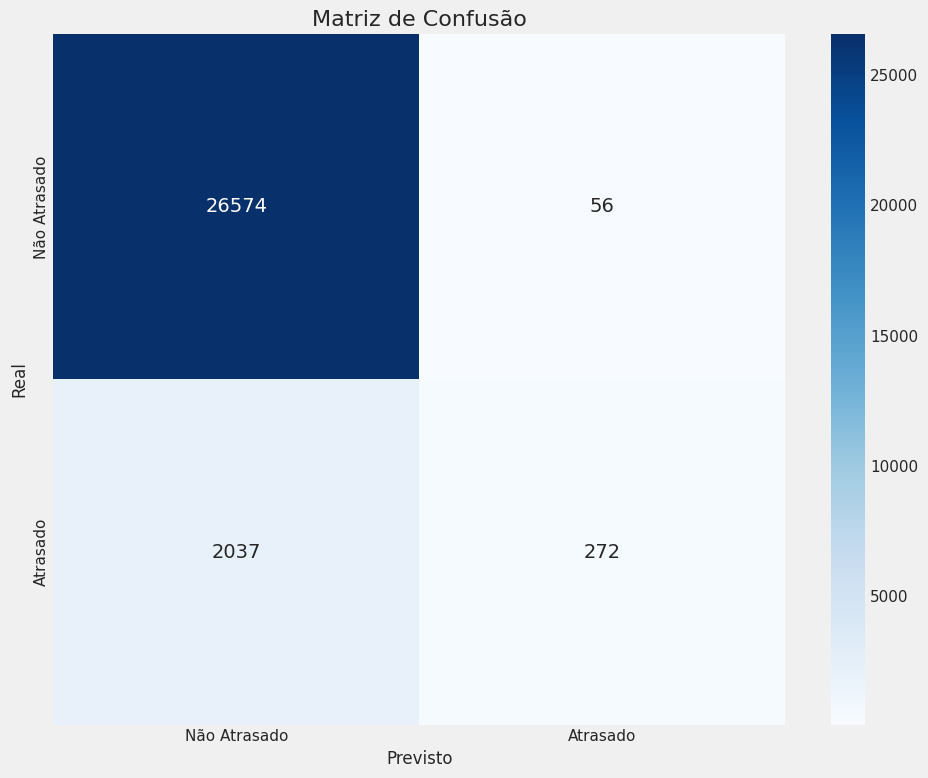

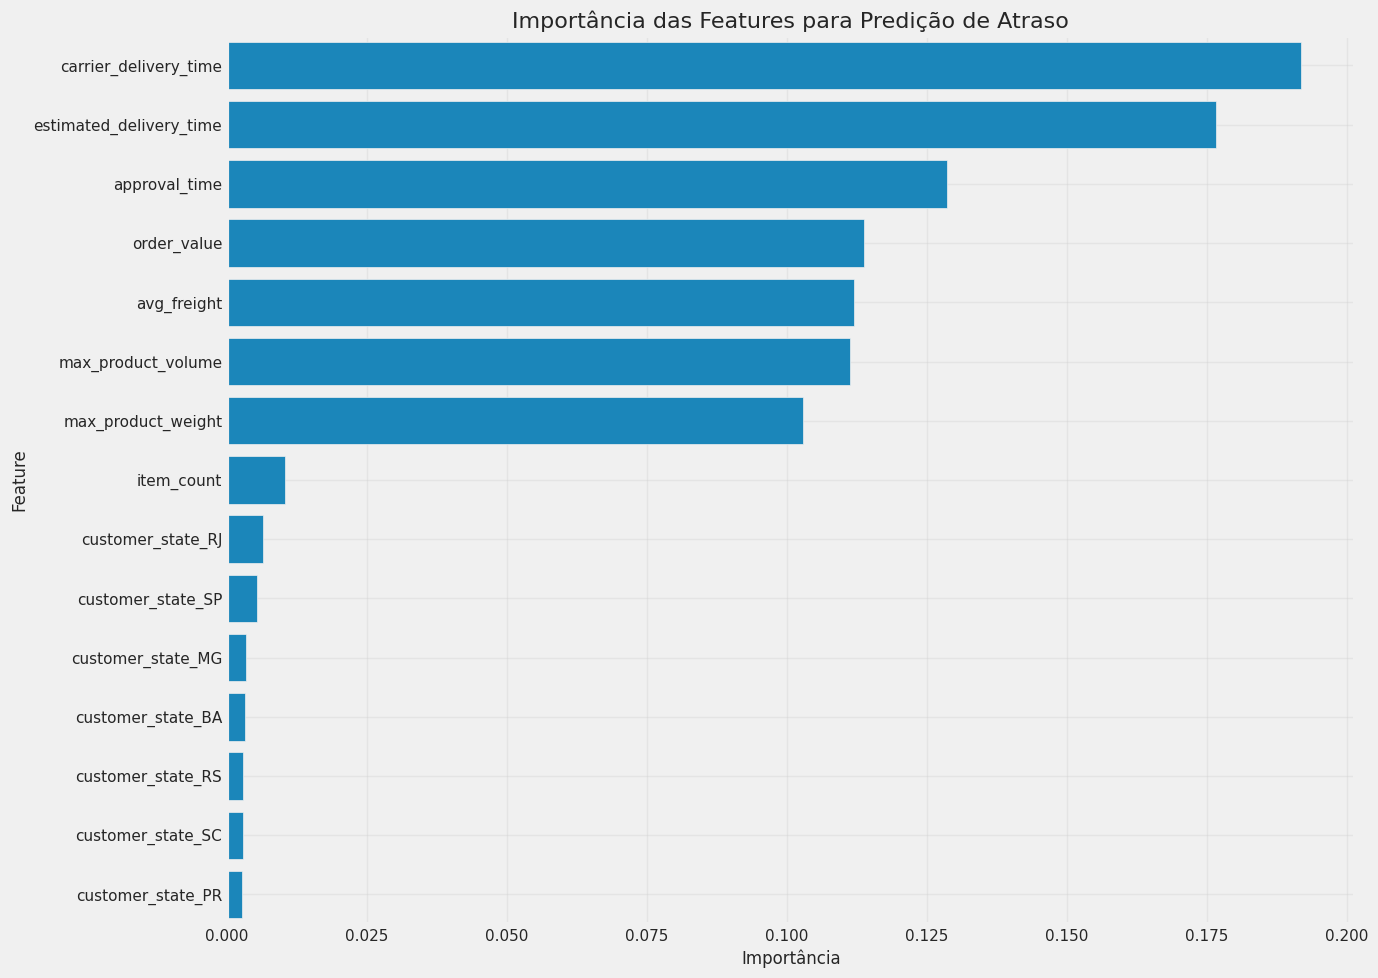

In [12]:
# Primeiro, vou definir o que é um pedido atrasado
# Considerando um pedido atrasado quando a data de entrega ao cliente for posterior à data estimada de entrega

# Consultando os dados necessários para o modelo
query = """
SELECT
    o.order_id,
    julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date) as delivery_delay,
    julianday(o.order_estimated_delivery_date) - julianday(o.order_purchase_timestamp) as estimated_delivery_time,
    julianday(o.order_approved_at) - julianday(o.order_purchase_timestamp) as approval_time,
    julianday(o.order_delivered_carrier_date) - julianday(o.order_approved_at) as carrier_delivery_time,
    c.customer_state,
    COUNT(oi.order_item_id) as item_count,
    SUM(oi.price) as order_value,
    AVG(oi.freight_value) as avg_freight,
    MAX(p.product_weight_g) as max_product_weight,
    MAX(p.product_length_cm * p.product_height_cm * p.product_width_cm) as max_product_volume
FROM
    orders o
JOIN
    customers c ON o.customer_id = c.customer_id
JOIN
    order_items oi ON o.order_id = oi.order_id
JOIN
    products p ON oi.product_id = p.product_id
WHERE
    o.order_delivered_customer_date IS NOT NULL
    AND o.order_estimated_delivery_date IS NOT NULL
    AND o.order_approved_at IS NOT NULL
    AND o.order_delivered_carrier_date IS NOT NULL
GROUP BY
    o.order_id, o.order_delivered_customer_date, o.order_estimated_delivery_date,
    o.order_purchase_timestamp, o.order_approved_at, o.order_delivered_carrier_date, c.customer_state
"""

delay_data = pd.read_sql_query(query, conn)

# Criando a variável target: 1 se atrasado, 0 se não atrasado
delay_data['is_delayed'] = (delay_data['delivery_delay'] > 0).astype(int)

# Verificando a distribuição da variável target
print("Distribuição de pedidos atrasados:")
print(delay_data['is_delayed'].value_counts())
print(f"Percentual de pedidos atrasados: {delay_data['is_delayed'].mean() * 100:.2f}%")

# Preparando os dados para o modelo
# Convertendo variáveis categóricas em dummies
delay_data = pd.get_dummies(delay_data, columns=['customer_state'], drop_first=True)

# Selecionando as features e o target
features = ['estimated_delivery_time', 'approval_time', 'carrier_delivery_time',
            'item_count', 'order_value', 'avg_freight', 'max_product_weight', 'max_product_volume'] + \
           [col for col in delay_data.columns if col.startswith('customer_state_')]

X = delay_data[features]
y = delay_data['is_delayed']

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalizando as features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinando o modelo Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Fazendo previsões
y_pred = rf_model.predict(X_test_scaled)

# Avaliando o modelo
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

print("\nMatriz de Confusão:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Visualizando a matriz de confusão
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Atrasado', 'Atrasado'],
            yticklabels=['Não Atrasado', 'Atrasado'])
plt.title('Matriz de Confusão', fontsize=16)
plt.xlabel('Previsto', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.show()

# Analisando a importância das features
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(14, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
plt.title('Importância das Features para Predição de Atraso', fontsize=16)
plt.xlabel('Importância', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 Segmentação de Clientes: Técnicas de Clusterign

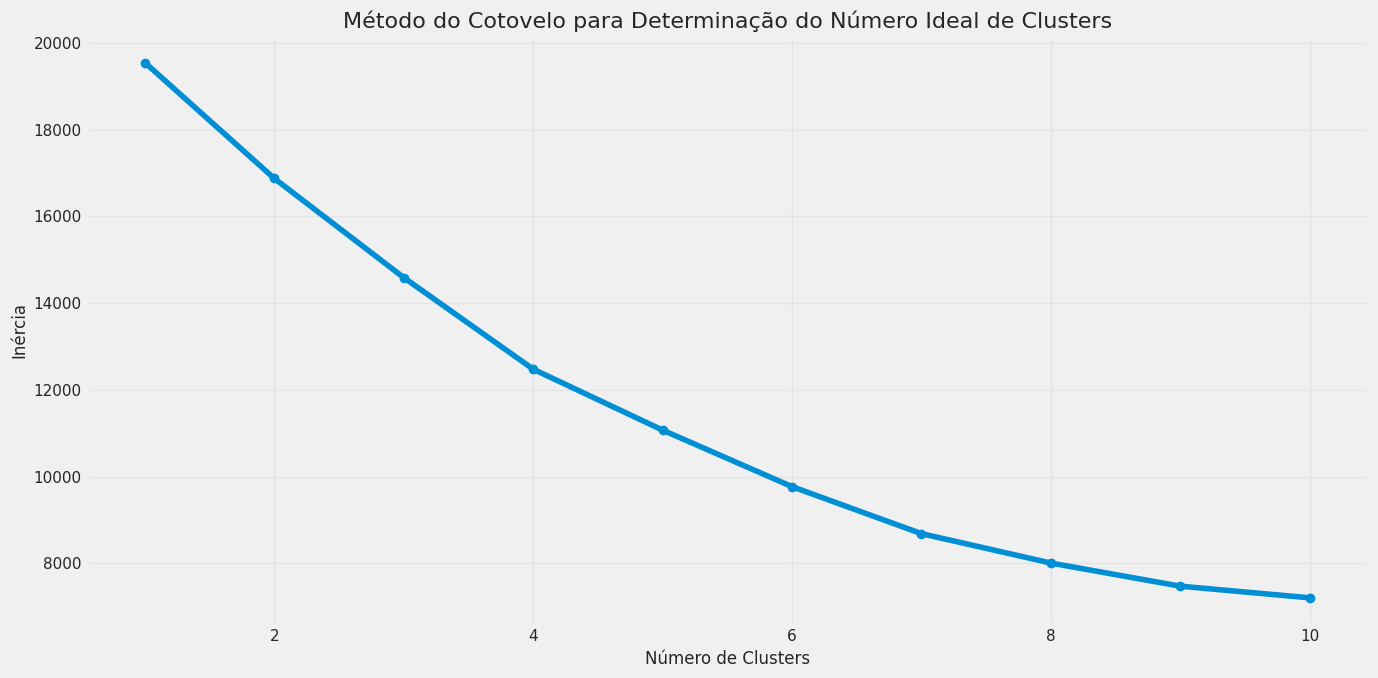

Análise dos Clusters:
         order_count  avg_delivery_time  total_spent  avg_order_value  \
cluster                                                                 
0           2.215385          13.398454  1264.309923       445.987183   
1           2.036524          10.692890   211.184181        85.691449   
2           2.342229          10.724461   252.417943        93.983076   
3           2.034325          19.907274   262.162471        93.153357   

         customer_lifetime_days  avg_review_score  category_count  \
cluster                                                             
0                     69.159881          4.202326        1.515385   
1                     36.397328          4.618321        1.457809   
2                    251.680563          4.447909        2.128728   
3                     44.692158          2.293751        1.491991   

         customer_count  
cluster                  
0                   130  
1                  1588  
2                   

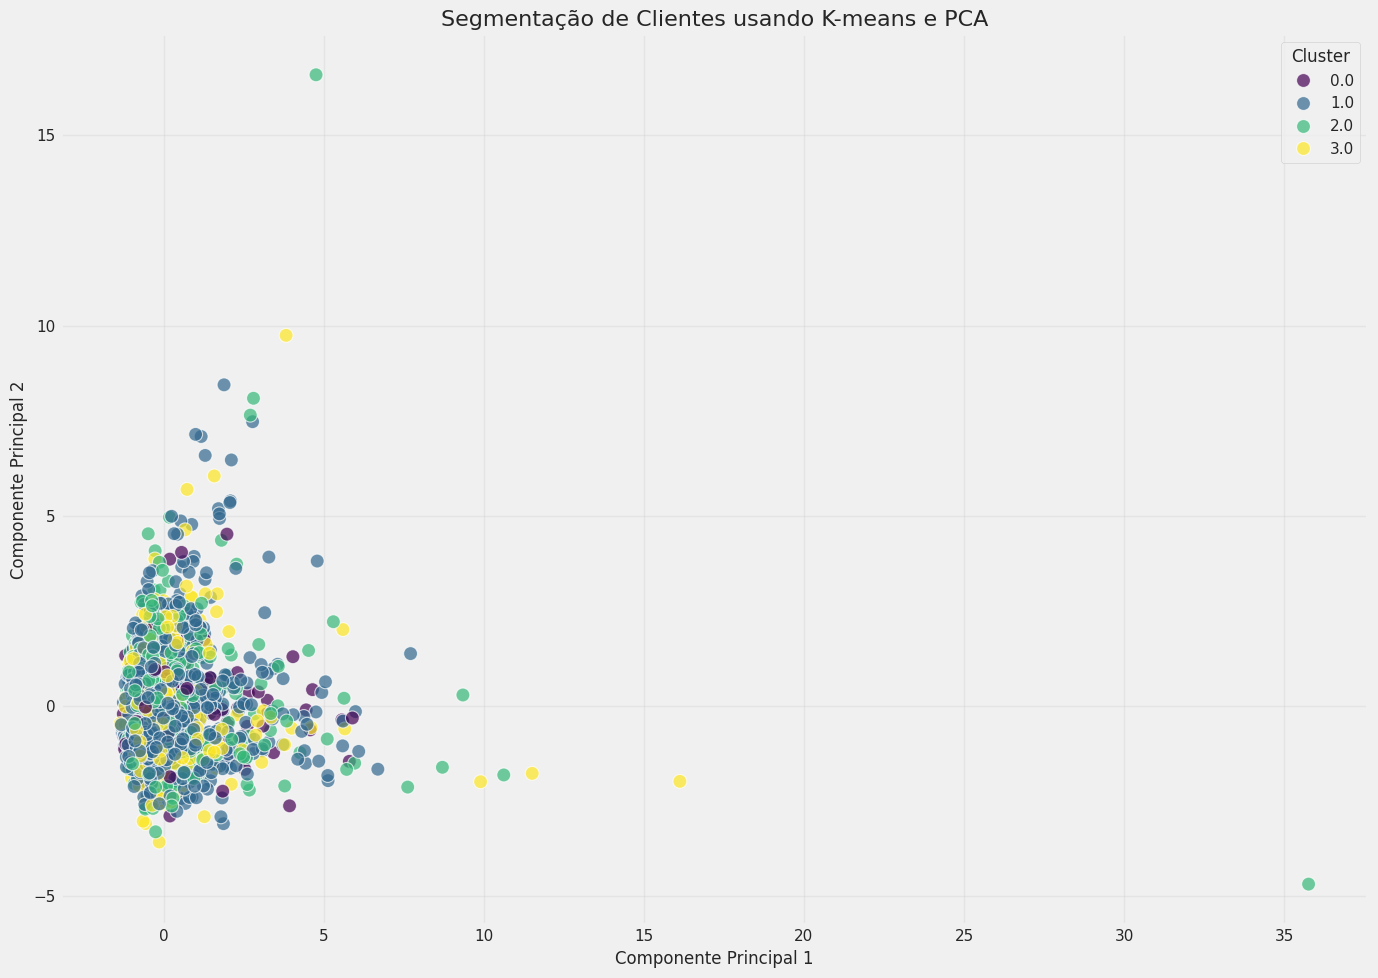

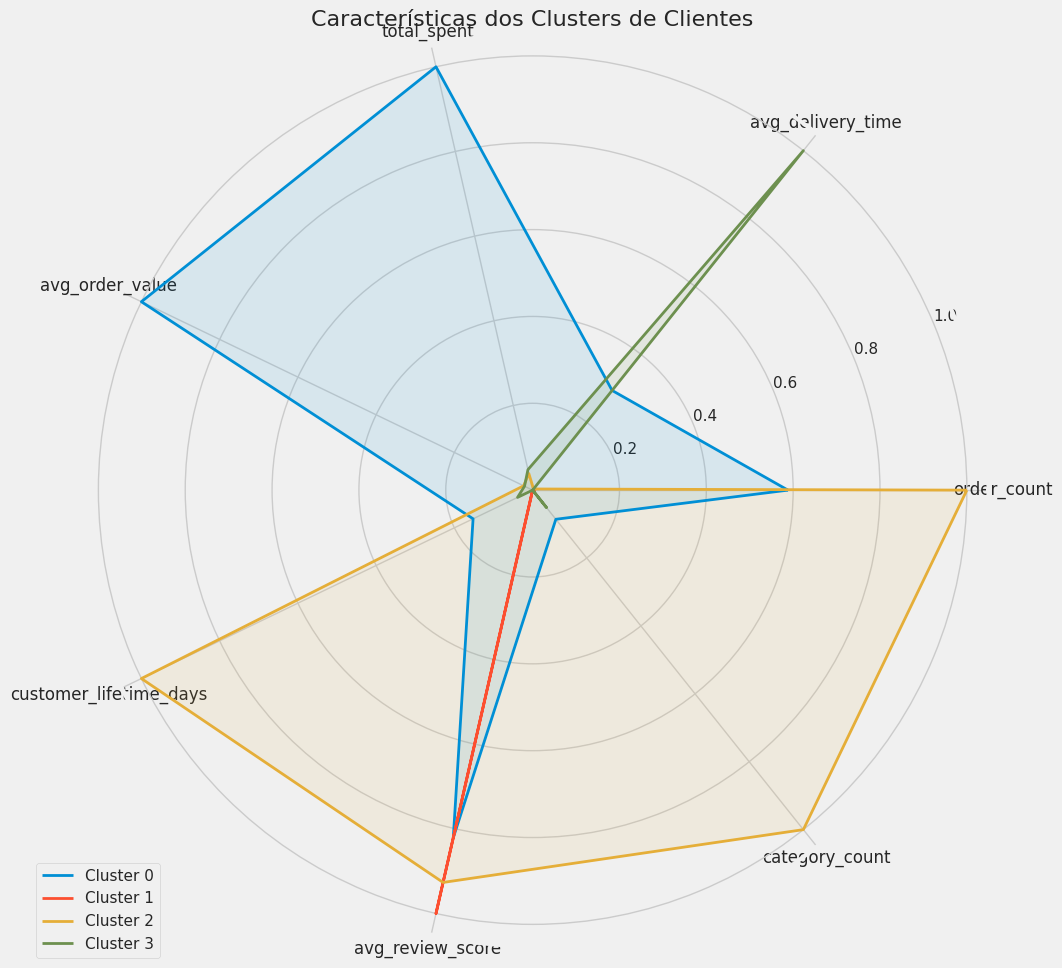

In [13]:
# Consultando os dados necessários para a segmentação de clientes
query = """
WITH customer_metrics AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) as order_count,
        AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) as avg_delivery_time,
        SUM(oi.price) as total_spent,
        AVG(oi.price) as avg_order_value,
        MAX(julianday(o.order_purchase_timestamp)) - MIN(julianday(o.order_purchase_timestamp)) as customer_lifetime_days,
        AVG(r.review_score) as avg_review_score,
        COUNT(DISTINCT p.product_category_name) as category_count
    FROM
        customers c
    JOIN
        orders o ON c.customer_id = o.customer_id
    JOIN
        order_items oi ON o.order_id = oi.order_id
    JOIN
        products p ON oi.product_id = p.product_id
    LEFT JOIN
        order_reviews r ON o.order_id = r.order_id
    WHERE
        o.order_delivered_customer_date IS NOT NULL
    GROUP BY
        c.customer_unique_id
)

SELECT * FROM customer_metrics
WHERE order_count > 1
"""

customer_segments = pd.read_sql_query(query, conn)

# Removendo valores nulos
customer_segments = customer_segments.dropna()

# Selecionando as features para clustering
cluster_features = ['order_count', 'avg_delivery_time', 'total_spent', 'avg_order_value',
                    'customer_lifetime_days', 'avg_review_score', 'category_count']

X_cluster = customer_segments[cluster_features]

# Normalizando as features
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Determinando o número ideal de clusters usando o método do cotovelo
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

# Plotando o gráfico do cotovelo
plt.figure(figsize=(14, 7))
plt.plot(k_range, inertia, marker='o')
plt.title('Método do Cotovelo para Determinação do Número Ideal de Clusters', fontsize=16)
plt.xlabel('Número de Clusters', fontsize=12)
plt.ylabel('Inércia', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Com base no gráfico do cotovelo, vamos escolher o número ideal de clusters
n_clusters = 4  # Ajuste conforme o resultado do gráfico

# Aplicando o K-means com o número ideal de clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
customer_segments['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Analisando os clusters
cluster_analysis = customer_segments.groupby('cluster').agg({
    'order_count': 'mean',
    'avg_delivery_time': 'mean',
    'total_spent': 'mean',
    'avg_order_value': 'mean',
    'customer_lifetime_days': 'mean',
    'avg_review_score': 'mean',
    'category_count': 'mean',
    'customer_unique_id': 'count'
}).rename(columns={'customer_unique_id': 'customer_count'})

print("Análise dos Clusters:")
print(cluster_analysis)

# Visualizando os clusters usando PCA para redução de dimensionalidade
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

# Criando um dataframe com os resultados do PCA
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = customer_segments['cluster']

# Plotando os clusters
plt.figure(figsize=(14, 10))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', s=100, alpha=0.7)
plt.title('Segmentação de Clientes usando K-means e PCA', fontsize=16)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Visualizando as características de cada cluster em um gráfico de radar
# Normalizando os valores para o gráfico de radar
radar_df = cluster_analysis.drop('customer_count', axis=1)
radar_df = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

# Criando o gráfico de radar
categories = radar_df.columns.tolist()
n_cats = len(categories)

# Calculando os ângulos para o gráfico de radar
angles = [n / float(n_cats) * 2 * np.pi for n in range(n_cats)]
angles += angles[:1]  # Fechando o círculo

# Criando a figura
fig, ax = plt.subplots(figsize=(14, 10), subplot_kw=dict(polar=True))

# Adicionando os eixos
plt.xticks(angles[:-1], categories, fontsize=12)

# Plotando cada cluster
for i, cluster in enumerate(radar_df.index):
    values = radar_df.loc[cluster].values.tolist()
    values += values[:1]  # Fechando o círculo
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {cluster}')
    ax.fill(angles, values, alpha=0.1)

plt.title('Características dos Clusters de Clientes', fontsize=16)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.tight_layout()
plt.show()

### 3.4 Análise de Satisfação: Relação entre Nota de Avaliação e Outros Fatores

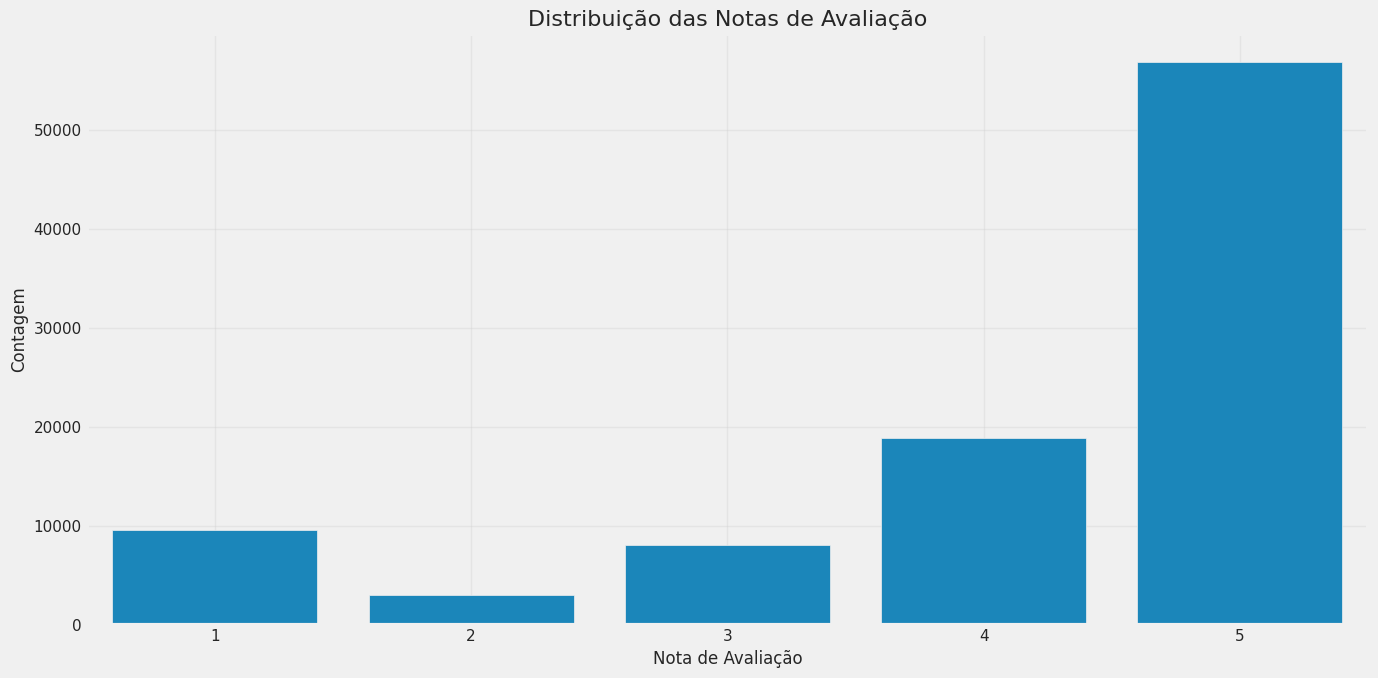

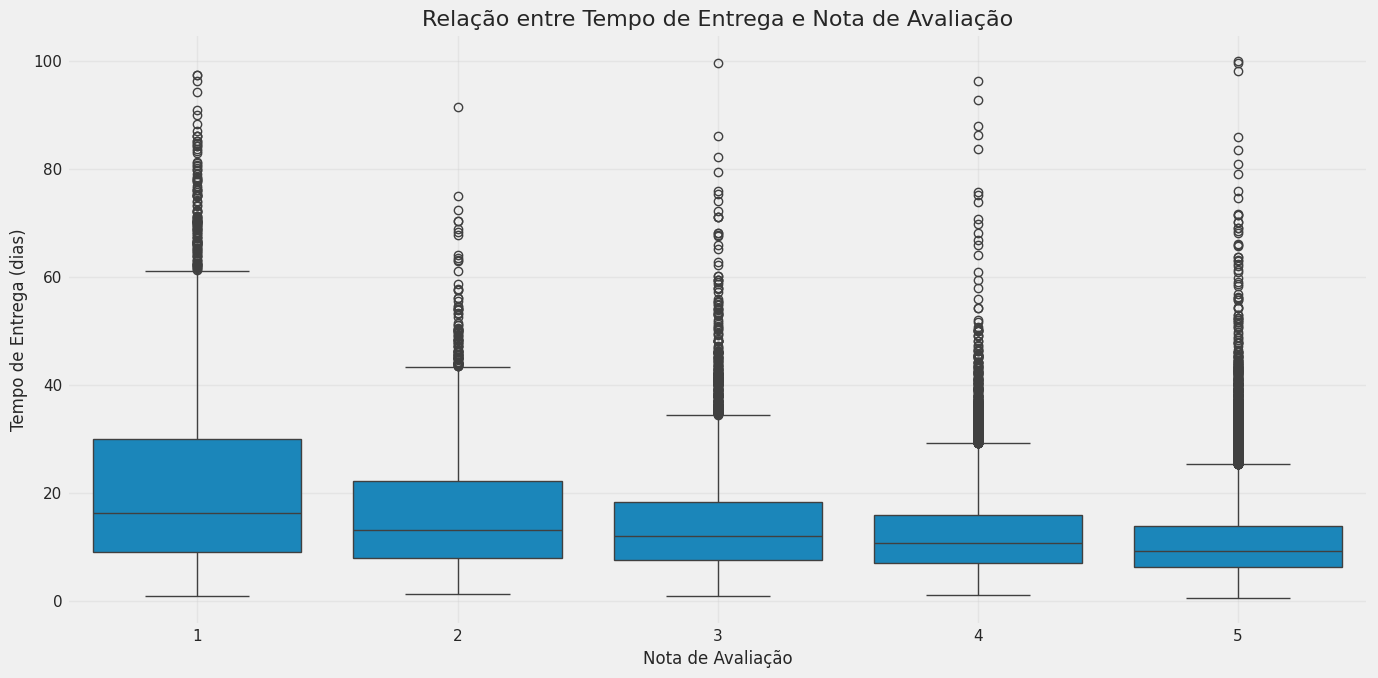

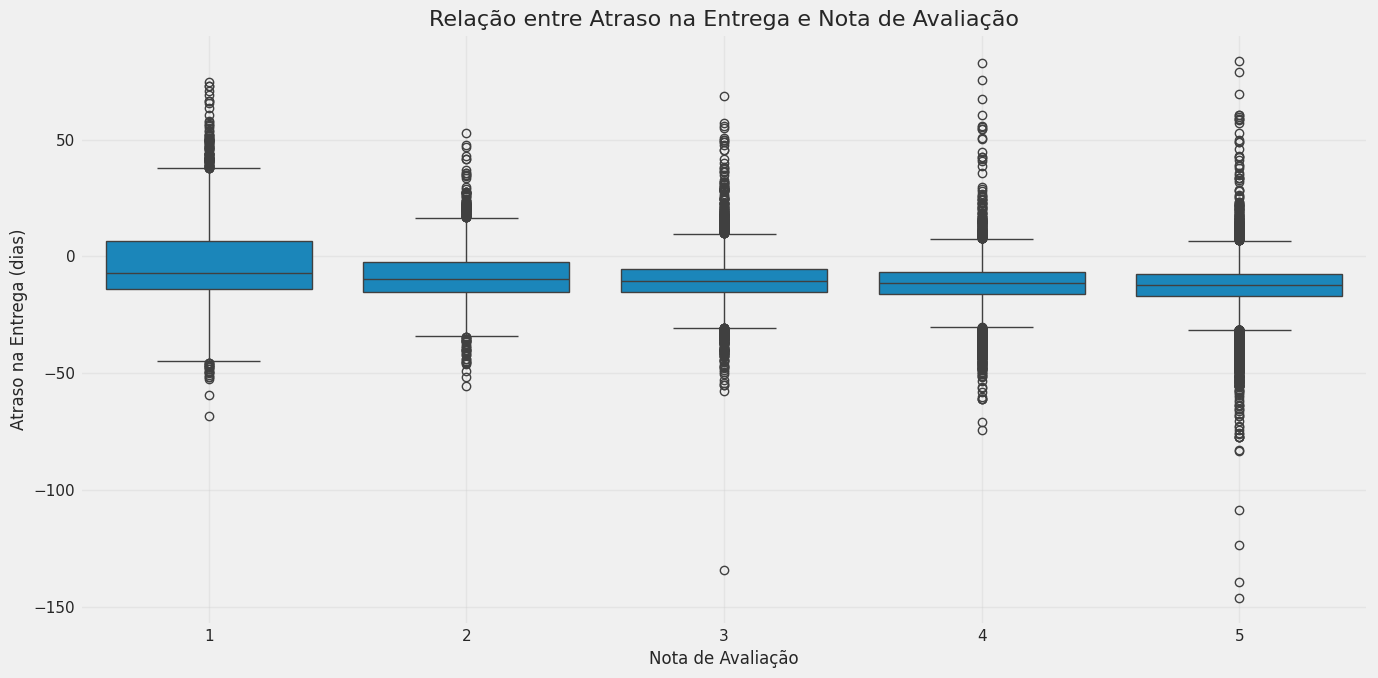

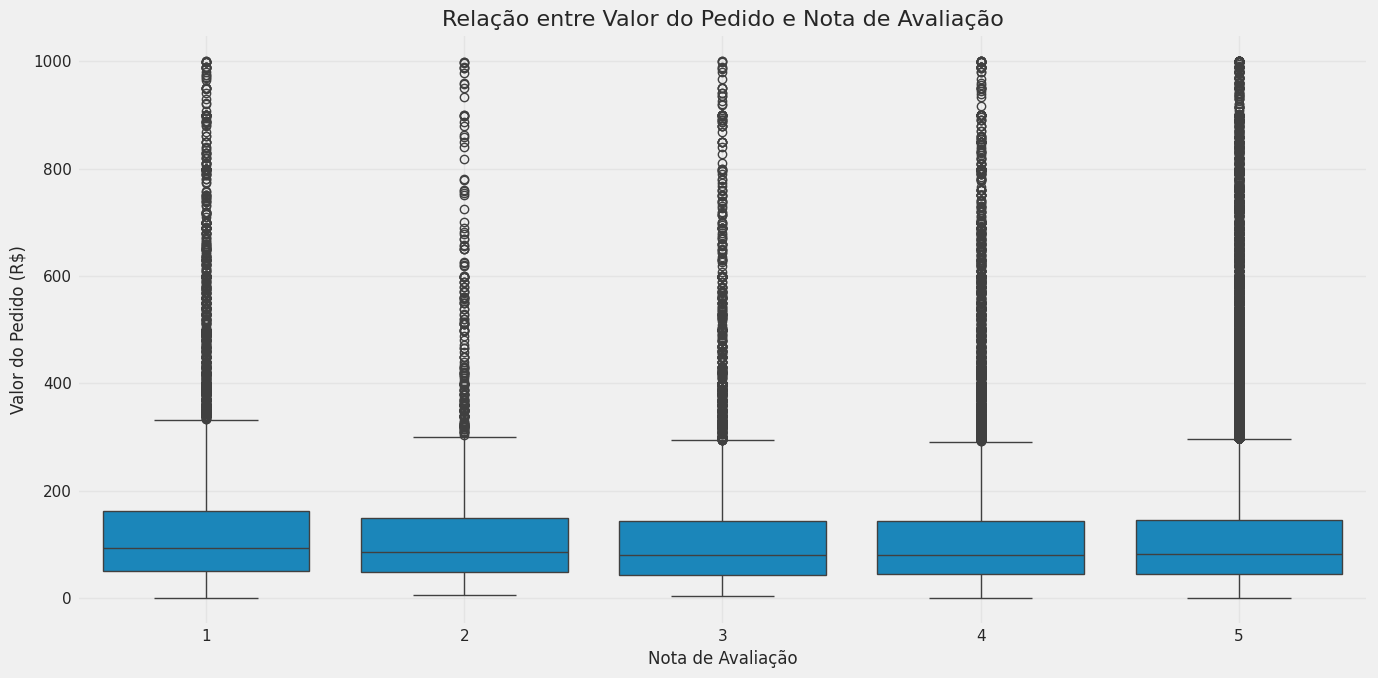

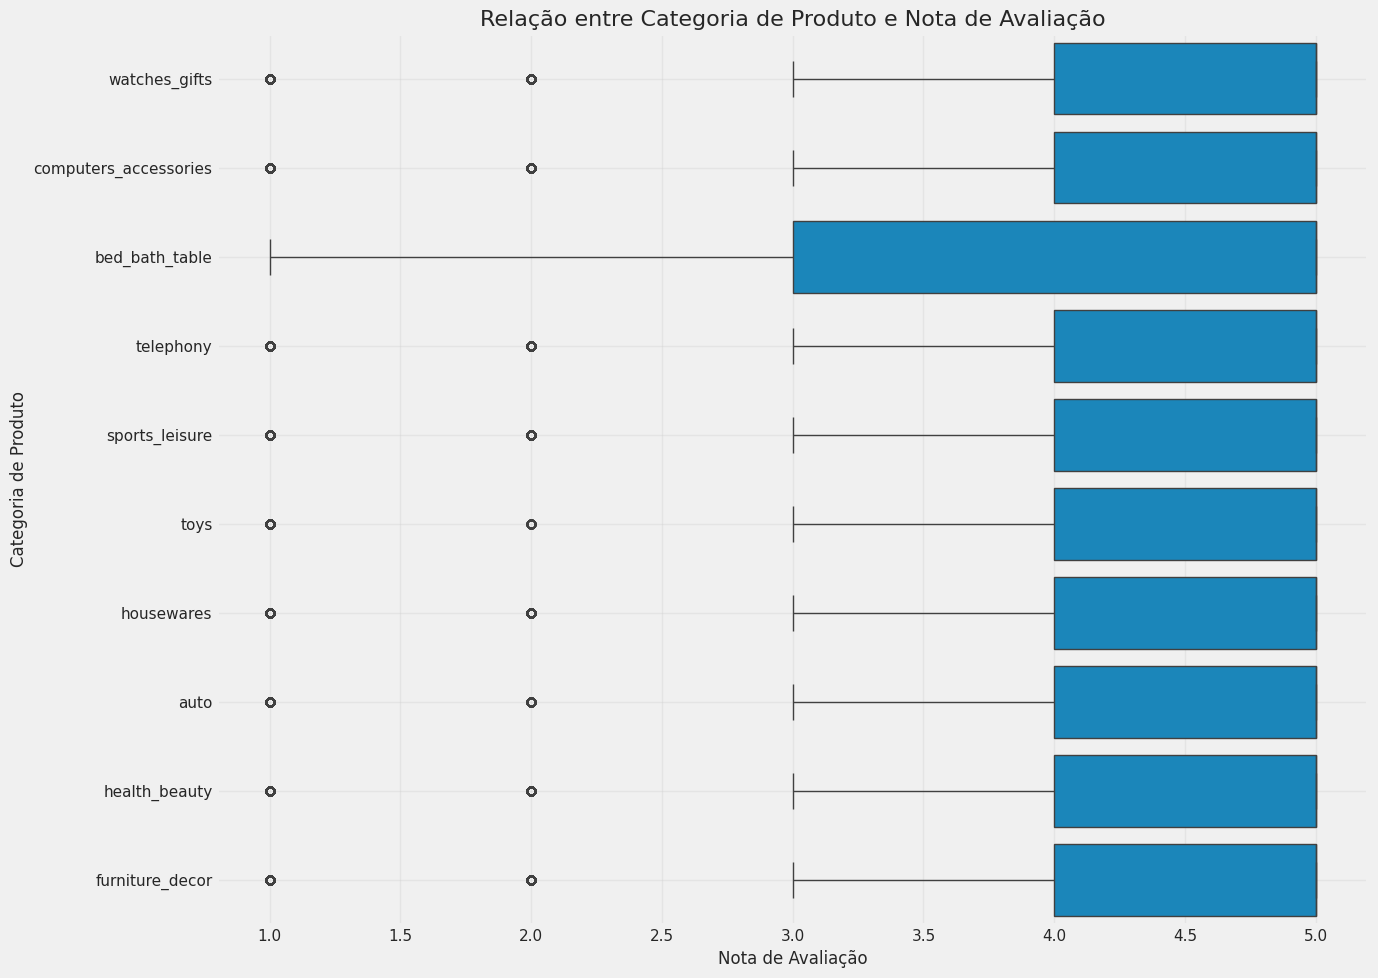

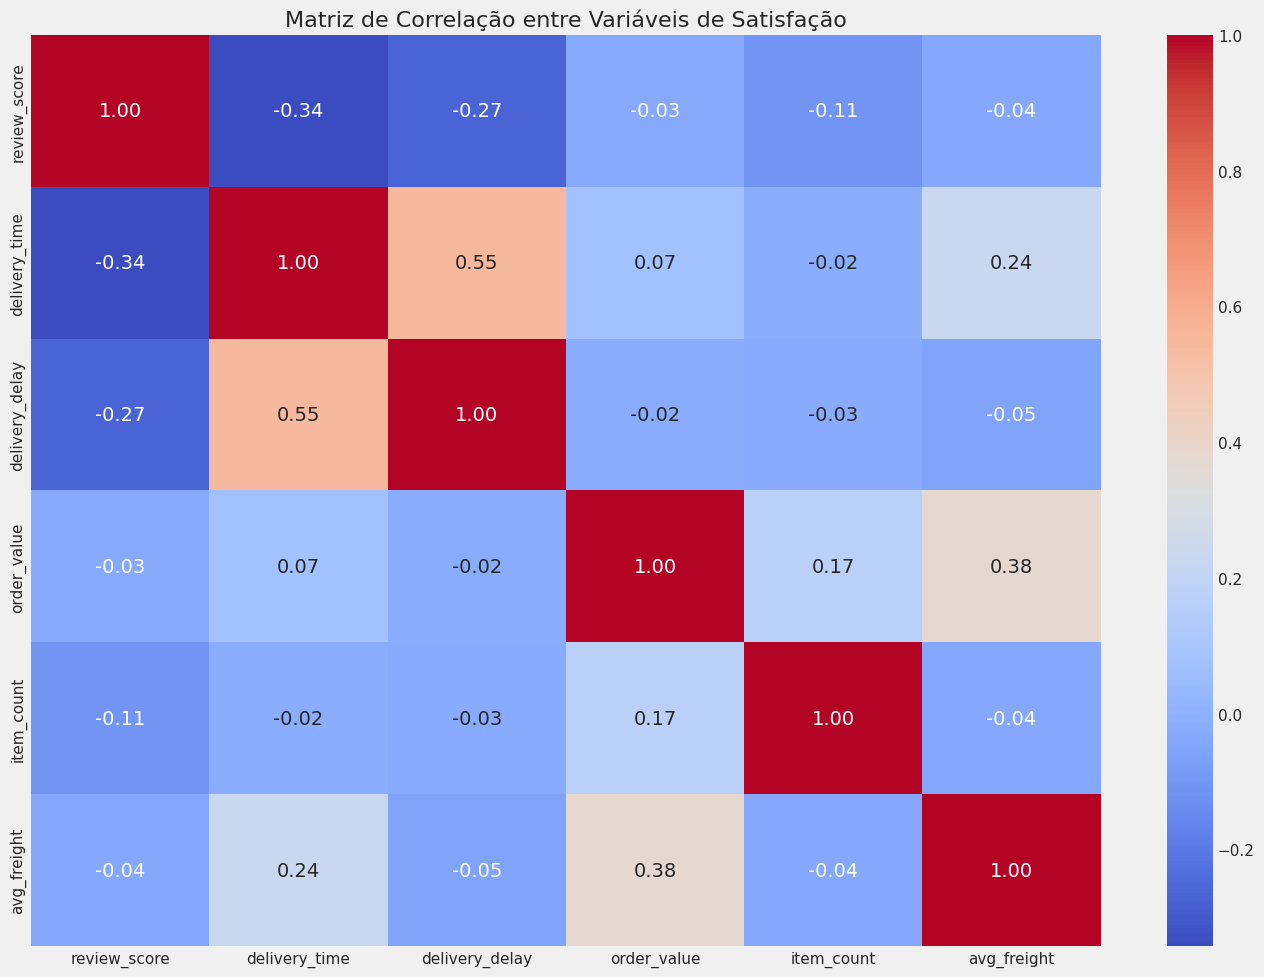

In [14]:
# Consultando os dados necessários para a análise de satisfação
query = """
SELECT
    r.review_score,
    julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp) as delivery_time,
    julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date) as delivery_delay,
    SUM(oi.price) as order_value,
    COUNT(oi.order_item_id) as item_count,
    AVG(oi.freight_value) as avg_freight,
    p.product_category_name,
    ct.product_category_name_english
FROM
    order_reviews r
JOIN
    orders o ON r.order_id = o.order_id
JOIN
    order_items oi ON o.order_id = oi.order_id
JOIN
    products p ON oi.product_id = p.product_id
LEFT JOIN
    category_translation ct ON p.product_category_name = ct.product_category_name
WHERE
    o.order_delivered_customer_date IS NOT NULL
    AND o.order_estimated_delivery_date IS NOT NULL
GROUP BY
    r.review_id, r.review_score, o.order_delivered_customer_date, o.order_purchase_timestamp,
    o.order_estimated_delivery_date, p.product_category_name, ct.product_category_name_english
"""

satisfaction_data = pd.read_sql_query(query, conn)

# Preenchendo categorias sem tradução
satisfaction_data['product_category_name_english'] = satisfaction_data['product_category_name_english'].fillna(satisfaction_data['product_category_name'])

# Removendo outliers para melhor visualização
satisfaction_data = satisfaction_data[(satisfaction_data['delivery_time'] < 100) & (satisfaction_data['order_value'] < 1000)]

# Analisando a distribuição das notas de avaliação
plt.figure(figsize=(14, 7))
sns.countplot(x='review_score', data=satisfaction_data)
plt.title('Distribuição das Notas de Avaliação', fontsize=16)
plt.xlabel('Nota de Avaliação', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analisando a relação entre tempo de entrega e nota de avaliação
plt.figure(figsize=(14, 7))
sns.boxplot(x='review_score', y='delivery_time', data=satisfaction_data)
plt.title('Relação entre Tempo de Entrega e Nota de Avaliação', fontsize=16)
plt.xlabel('Nota de Avaliação', fontsize=12)
plt.ylabel('Tempo de Entrega (dias)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analisando a relação entre atraso na entrega e nota de avaliação
plt.figure(figsize=(14, 7))
sns.boxplot(x='review_score', y='delivery_delay', data=satisfaction_data)
plt.title('Relação entre Atraso na Entrega e Nota de Avaliação', fontsize=16)
plt.xlabel('Nota de Avaliação', fontsize=12)
plt.ylabel('Atraso na Entrega (dias)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analisando a relação entre valor do pedido e nota de avaliação
plt.figure(figsize=(14, 7))
sns.boxplot(x='review_score', y='order_value', data=satisfaction_data)
plt.title('Relação entre Valor do Pedido e Nota de Avaliação', fontsize=16)
plt.xlabel('Nota de Avaliação', fontsize=12)
plt.ylabel('Valor do Pedido (R$)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analisando a relação entre categoria de produto e nota de avaliação
# Pegando as top 10 categorias mais frequentes
top_categories = satisfaction_data['product_category_name_english'].value_counts().head(10).index
category_satisfaction = satisfaction_data[satisfaction_data['product_category_name_english'].isin(top_categories)]

plt.figure(figsize=(14, 10))
sns.boxplot(x='review_score', y='product_category_name_english', data=category_satisfaction)
plt.title('Relação entre Categoria de Produto e Nota de Avaliação', fontsize=16)
plt.xlabel('Nota de Avaliação', fontsize=12)
plt.ylabel('Categoria de Produto', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculando a correlação entre as variáveis numéricas
correlation_matrix = satisfaction_data[['review_score', 'delivery_time', 'delivery_delay', 'order_value', 'item_count', 'avg_freight']].corr()

# Plotando o mapa de calor da matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação entre Variáveis de Satisfação', fontsize=16)
plt.tight_layout()
plt.show()

## 4. Visualização e Dashboards

Nesta seção, vou criar visualizações e dashboards interativos para responder às necessidades específicas do desafio.

In [15]:
# Consultando os dados necessários para o dashboard de evolução das vendas
query = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) as year_month,
    c.customer_state,
    p.product_category_name,
    ct.product_category_name_english,
    COUNT(DISTINCT o.order_id) as order_count,
    SUM(oi.price) as total_revenue
FROM
    orders o
JOIN
    customers c ON o.customer_id = c.customer_id
JOIN
    order_items oi ON o.order_id = oi.order_id
JOIN
    products p ON oi.product_id = p.product_id
LEFT JOIN
    category_translation ct ON p.product_category_name = ct.product_category_name
GROUP BY
    year_month, c.customer_state, p.product_category_name, ct.product_category_name_english
ORDER BY
    year_month
"""

sales_evolution = pd.read_sql_query(query, conn)

# Preenchendo categorias sem tradução
sales_evolution['product_category_name_english'] = sales_evolution['product_category_name_english'].fillna(sales_evolution['product_category_name'])

# Convertendo a coluna year_month para datetime para melhor visualização
sales_evolution['year_month'] = pd.to_datetime(sales_evolution['year_month'] + '-01')

# Criando um dashboard interativo com Plotly
# Agregando os dados por mês
monthly_sales = sales_evolution.groupby('year_month').agg({
    'order_count': 'sum',
    'total_revenue': 'sum'
}).reset_index()

# Criando o dashboard
fig = make_subplots(rows=2, cols=1, subplot_titles=('Evolução do Número de Pedidos', 'Evolução do Faturamento'),
                    vertical_spacing=0.1, shared_xaxes=True)

# Adicionando o gráfico de evolução do número de pedidos
fig.add_trace(
    go.Scatter(x=monthly_sales['year_month'], y=monthly_sales['order_count'], mode='lines+markers',
              name='Número de Pedidos'),
    row=1, col=1
)

# Adicionando o gráfico de evolução do faturamento
fig.add_trace(
    go.Scatter(x=monthly_sales['year_month'], y=monthly_sales['total_revenue'], mode='lines+markers',
              name='Faturamento (R$)'),
    row=2, col=1
)

# Atualizando o layout
fig.update_layout(
    title='Evolução das Vendas ao Longo do Tempo',
    height=800,
    width=1000,
    showlegend=True
)

# Exibindo o dashboard
fig.show()

# Criando um dashboard interativo com filtros por estado e categoria
# Usando Plotly Express para criar um dashboard mais completo
fig = px.line(sales_evolution, x='year_month', y='total_revenue', color='customer_state',
             title='Evolução do Faturamento por Estado',
             labels={'year_month': 'Mês', 'total_revenue': 'Faturamento (R$)', 'customer_state': 'Estado'})

fig.update_layout(height=600, width=1000)
fig.show()

# Dashboard por categoria de produto
# Agregando os dados por categoria
category_sales = sales_evolution.groupby(['year_month', 'product_category_name_english']).agg({
    'order_count': 'sum',
    'total_revenue': 'sum'
}).reset_index()

# Pegando as top 10 categorias por faturamento
top_categories = category_sales.groupby('product_category_name_english')['total_revenue'].sum().nlargest(10).index
category_sales_filtered = category_sales[category_sales['product_category_name_english'].isin(top_categories)]

# Criando o dashboard por categoria
fig = px.line(category_sales_filtered, x='year_month', y='total_revenue', color='product_category_name_english',
             title='Evolução do Faturamento por Categoria de Produto (Top 10)',
             labels={'year_month': 'Mês', 'total_revenue': 'Faturamento (R$)', 'product_category_name_english': 'Categoria'})

fig.update_layout(height=600, width=1000)
fig.show()

### 4.2 Mapa de Calor de Vendas por Região/Estado

In [16]:
# Consultando os dados necessários para o mapa de calor
query = """
SELECT
    c.customer_state,
    COUNT(DISTINCT o.order_id) as order_count,
    SUM(oi.price) as total_revenue
FROM
    orders o
JOIN
    customers c ON o.customer_id = c.customer_id
JOIN
    order_items oi ON o.order_id = oi.order_id
GROUP BY
    c.customer_state
ORDER BY
    total_revenue DESC
"""

state_sales = pd.read_sql_query(query, conn)

# Criando um dicionário com os nomes completos dos estados
state_names = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas', 'BA': 'Bahia',
    'CE': 'Ceará', 'DF': 'Distrito Federal', 'ES': 'Espírito Santo', 'GO': 'Goiás',
    'MA': 'Maranhão', 'MT': 'Mato Grosso', 'MS': 'Mato Grosso do Sul', 'MG': 'Minas Gerais',
    'PA': 'Pará', 'PB': 'Paraíba', 'PR': 'Paraná', 'PE': 'Pernambuco', 'PI': 'Piauí',
    'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte', 'RS': 'Rio Grande do Sul',
    'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina', 'SP': 'São Paulo',
    'SE': 'Sergipe', 'TO': 'Tocantins'
}

# Adicionando os nomes completos dos estados
state_sales['state_name'] = state_sales['customer_state'].map(state_names)

# Criando o mapa de calor usando Plotly
fig = px.choropleth(
    state_sales,
    locations='customer_state',
    locationmode='ISO-3',
    color='total_revenue',
    hover_name='state_name',
    hover_data=['order_count', 'total_revenue'],
    color_continuous_scale='Viridis',
    scope='south america',
    title='Mapa de Calor de Vendas por Estado Brasileiro'
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(height=600, margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

# Criando um mapa de calor para o número de pedidos
fig = px.choropleth(
    state_sales,
    locations='customer_state',
    locationmode='ISO-3',
    color='order_count',
    hover_name='state_name',
    hover_data=['order_count', 'total_revenue'],
    color_continuous_scale='Viridis',
    scope='south america',
    title='Mapa de Calor do Número de Pedidos por Estado Brasileiro'
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(height=600, margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

### 4.3 Relação entre Avaliação do Cliente e Tempo de Entrega

In [17]:
# Consultando os dados necessários para a análise da relação entre avaliação e tempo de entrega
query = """
SELECT
    r.review_score,
    julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp) as delivery_time,
    julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date) as delivery_delay,
    CASE
        WHEN julianday(o.order_delivered_customer_date) > julianday(o.order_estimated_delivery_date) THEN 'Atrasado'
        ELSE 'No Prazo'
    END as delivery_status
FROM
    order_reviews r
JOIN
    orders o ON r.order_id = o.order_id
WHERE
    o.order_delivered_customer_date IS NOT NULL
    AND o.order_estimated_delivery_date IS NOT NULL
"""

review_delivery = pd.read_sql_query(query, conn)

# Removendo outliers para melhor visualização
review_delivery = review_delivery[review_delivery['delivery_time'] < 100]

# Criando um conjunto de gráficos para visualizar a relação
fig = make_subplots(rows=2, cols=2, subplot_titles=(
    'Distribuição do Tempo de Entrega por Nota',
    'Distribuição do Atraso na Entrega por Nota',
    'Tempo Médio de Entrega por Nota',
    'Proporção de Entregas Atrasadas por Nota'
))

# Gráfico 1: Boxplot do tempo de entrega por nota
for score in sorted(review_delivery['review_score'].unique()):
    fig.add_trace(
        go.Box(y=review_delivery[review_delivery['review_score'] == score]['delivery_time'],
              name=f'Nota {score}'),
        row=1, col=1
    )

# Gráfico 2: Boxplot do atraso na entrega por nota
for score in sorted(review_delivery['review_score'].unique()):
    fig.add_trace(
        go.Box(y=review_delivery[review_delivery['review_score'] == score]['delivery_delay'],
              name=f'Nota {score}'),
        row=1, col=2
    )

# Gráfico 3: Tempo médio de entrega por nota
avg_delivery_time = review_delivery.groupby('review_score')['delivery_time'].mean().reset_index()
fig.add_trace(
    go.Bar(x=avg_delivery_time['review_score'], y=avg_delivery_time['delivery_time'],
          name='Tempo Médio de Entrega'),
    row=2, col=1
)

# Gráfico 4: Proporção de entregas atrasadas por nota
delayed_proportion = review_delivery.groupby('review_score')['delivery_status'].apply(
    lambda x: (x == 'Atrasado').mean() * 100
).reset_index()
delayed_proportion.columns = ['review_score', 'delayed_percentage']

fig.add_trace(
    go.Bar(x=delayed_proportion['review_score'], y=delayed_proportion['delayed_percentage'],
          name='Percentual de Entregas Atrasadas'),
    row=2, col=2
)

# Atualizando o layout
fig.update_layout(
    title='Relação entre Avaliação do Cliente e Tempo de Entrega',
    height=800,
    width=1000,
    showlegend=False
)

# Atualizando os eixos
fig.update_yaxes(title_text='Tempo de Entrega (dias)', row=1, col=1)
fig.update_yaxes(title_text='Atraso na Entrega (dias)', row=1, col=2)
fig.update_yaxes(title_text='Tempo Médio de Entrega (dias)', row=2, col=1)
fig.update_yaxes(title_text='Percentual de Entregas Atrasadas (%)', row=2, col=2)

fig.update_xaxes(title_text='Nota de Avaliação', row=2, col=1)
fig.update_xaxes(title_text='Nota de Avaliação', row=2, col=2)

# Exibindo o conjunto de gráficos
fig.show()

### 4.4 Dashboard de Análise dos Vendedores

In [18]:
# Consultando os dados necessários para a análise dos vendedores
query = """
SELECT
    s.seller_id,
    s.seller_state,
    COUNT(DISTINCT oi.order_id) as order_count,
    SUM(oi.price) as total_revenue,
    AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) as avg_delivery_time,
    AVG(r.review_score) as avg_review_score,
    COUNT(DISTINCT p.product_category_name) as category_count
FROM
    sellers s
JOIN
    order_items oi ON s.seller_id = oi.seller_id
JOIN
    orders o ON oi.order_id = o.order_id
JOIN
    products p ON oi.product_id = p.product_id
LEFT JOIN
    order_reviews r ON o.order_id = r.order_id
WHERE
    o.order_delivered_customer_date IS NOT NULL
GROUP BY
    s.seller_id, s.seller_state
HAVING
    order_count >= 10
ORDER BY
    total_revenue DESC
"""

seller_analysis = pd.read_sql_query(query, conn)

# Pegando os top 20 vendedores por faturamento
top_sellers = seller_analysis.head(20)

# Criando um dashboard interativo para análise dos vendedores
fig = make_subplots(rows=2, cols=2, subplot_titles=(
    'Top 20 Vendedores por Faturamento',
    'Relação entre Faturamento e Avaliação',
    'Relação entre Tempo de Entrega e Avaliação',
    'Distribuição dos Vendedores por Estado'
))

# Gráfico 1: Top 20 vendedores por faturamento
fig.add_trace(
    go.Bar(x=top_sellers['seller_id'], y=top_sellers['total_revenue'],
          name='Faturamento Total (R$)'),
    row=1, col=1
)

# Gráfico 2: Relação entre faturamento e avaliação
fig.add_trace(
    go.Scatter(x=seller_analysis['total_revenue'], y=seller_analysis['avg_review_score'],
              mode='markers', name='Vendedores',
              marker=dict(size=8, color=seller_analysis['order_count'], colorscale='Viridis',
                         showscale=True, colorbar=dict(title='Número de Pedidos'))),
    row=1, col=2
)

# Gráfico 3: Relação entre tempo de entrega e avaliação
fig.add_trace(
    go.Scatter(x=seller_analysis['avg_delivery_time'], y=seller_analysis['avg_review_score'],
              mode='markers', name='Vendedores',
              marker=dict(size=8, color=seller_analysis['total_revenue'], colorscale='Viridis',
                         showscale=True, colorbar=dict(title='Faturamento (R$)'))),
    row=2, col=1
)

# Gráfico 4: Distribuição dos vendedores por estado
state_count = seller_analysis['seller_state'].value_counts().reset_index()
state_count.columns = ['seller_state', 'count']

fig.add_trace(
    go.Bar(x=state_count['seller_state'], y=state_count['count'],
          name='Número de Vendedores'),
    row=2, col=2
)

# Atualizando o layout
fig.update_layout(
    title='Dashboard de Análise dos Vendedores',
    height=1000,
    width=1200,
    showlegend=False
)

# Atualizando os eixos
fig.update_xaxes(title_text='Vendedor ID', row=1, col=1, tickangle=45)
fig.update_xaxes(title_text='Faturamento Total (R$)', row=1, col=2)
fig.update_xaxes(title_text='Tempo Médio de Entrega (dias)', row=2, col=1)
fig.update_xaxes(title_text='Estado', row=2, col=2)

fig.update_yaxes(title_text='Faturamento Total (R$)', row=1, col=1)
fig.update_yaxes(title_text='Nota Média de Avaliação', row=1, col=2)
fig.update_yaxes(title_text='Nota Média de Avaliação', row=2, col=1)
fig.update_yaxes(title_text='Número de Vendedores', row=2, col=2)

# Exibindo o dashboard
fig.show()

# Criando um dashboard adicional para análise de desempenho dos vendedores
# Calculando métricas de desempenho
seller_analysis['revenue_per_order'] = seller_analysis['total_revenue'] / seller_analysis['order_count']
seller_analysis['efficiency_score'] = (seller_analysis['avg_review_score'] / 5) * (1 - seller_analysis['avg_delivery_time'] / seller_analysis['avg_delivery_time'].max())

# Criando um ranking dos vendedores
seller_analysis['revenue_rank'] = seller_analysis['total_revenue'].rank(ascending=False)
seller_analysis['review_rank'] = seller_analysis['avg_review_score'].rank(ascending=False)
seller_analysis['delivery_rank'] = seller_analysis['avg_delivery_time'].rank()
seller_analysis['overall_rank'] = (seller_analysis['revenue_rank'] + seller_analysis['review_rank'] + seller_analysis['delivery_rank']) / 3

# Pegando os top 20 vendedores pelo ranking geral
top_performers = seller_analysis.sort_values('overall_rank').head(20)

# Criando um dashboard para os top performers
fig = px.scatter(top_performers, x='avg_review_score', y='avg_delivery_time',
                size='total_revenue', color='seller_state', hover_name='seller_id',
                hover_data=['order_count', 'total_revenue', 'revenue_per_order', 'efficiency_score'],
                title='Top 20 Vendedores por Desempenho Geral')

fig.update_layout(height=600, width=1000)
fig.update_xaxes(title='Nota Média de Avaliação')
fig.update_yaxes(title='Tempo Médio de Entrega (dias)')

fig.show()

                          📊 Conclusões Gerais do Projeto
1. Preparação dos Dados
Modelo Relacional : Um modelo relacional foi criado para facilitar consultas SQL e integrar os dados das tabelas.
Tratamento de Nulos e Duplicatas : Valores nulos foram tratados adequadamente, e duplicatas foram identificadas e removidas quando necessário.
Criação de Variáveis Derivadas : Novas variáveis como avg_delivery_time, total_spent e customer_lifetime_days foram calculadas para melhor análise.

2. Análise Exploratória de Dados (EDA)
🛍️ Vendas e Sazonalidade
Volume de Pedidos por Mês :
Crescimento contínuo no número de pedidos ao longo do período analisado (2016–2018).

Picos sazonais consistentes nos meses finais do ano (novembro e dezembro), indicando comportamento típico de compras festivas.
Declínio abrupto em outubro de 2018, sugerindo um evento atípico ou mudança estratégica.

Sazonalidade Anual :
O padrão sazonal é consistente entre os anos, com picos nas vendas durante o final do ano.

🕒 Tempo de Entrega
Distribuição do Tempo de Entrega :
A maioria dos pedidos é entregue dentro de 15 a 30 dias , mas há casos extremos com tempos de entrega muito longos (>100 dias).
Atrasos na entrega estão fortemente associados a avaliações negativas dos clientes.

🚚 Relação entre Frete e Distância
Existe uma correlação positiva entre o valor do frete e a distância de entrega, embora não seja linear.

Algumas regiões têm valores de frete mais altos que o esperado, possivelmente devido a fatores logísticos específicos.

🏷️ Categorias Mais Vendidas
As categorias com maior faturamento são:

health_beauty
watches_gifts
bed_bath_table
sports_leisure
computers_accessories
🌎 Estados com Maior Valor Médio de Pedido
Os estados com os maiores valores médios de pedido são:

PB (Paraíba)
AC (Acre)
AP (Amapá)

3. Análise de Retenção de Clientes
Taxa de Clientes Recorrentes : Apenas 3.1% dos clientes voltam a comprar, indicando baixa retenção.
Intervalo Entre Compras : A maioria dos clientes recorrentes realiza novas compras após 30 a 90 dias , sugerindo oportunidades para campanhas de remarketing.

4. Modelagem Preditiva: Previsão de Atrasos
🧠 Modelo de Random Forest
Acurácia : ~93%
Recall : Baixo (~27%), indicando dificuldade em identificar corretamente os casos de atraso.
Features Importantes :
carrier_delivery_time
estimated_delivery_time
approval_time
order_value

✅ Conclusão
O modelo pode ser refinado para melhorar a detecção de atrasos, especialmente utilizando técnicas de balanceamento de classes ou modelos mais robustos.

5. Segmentação de Clientes
🔍 K-means Clustering
Identificados 4 clusters distintos de clientes com características únicas:

0
Clientes fiéis – alto valor gasto, muitas compras, satisfeitos
1
Compradores ocasionais – baixo gasto, poucas compras, alta satisfação
2
Novos clientes – compras recentes, média satisfação
3
Clientes insatisfeitos – poucos pedidos, avaliações ruins

💡 Insights Práticos
Campanhas personalizadas podem ser direcionadas para cada grupo:

Fidelização para o Cluster 0
Reativação para o Cluster 3

6. Análise de Satisfação do Cliente
⭐ Relação entre Avaliação e Tempo de Entrega
Notas baixas estão fortemente associadas a atrasos na entrega .
Categorias específicas (como "health_beauty" e "watches_gifts") tendem a ter avaliações mais altas.

🔗 Matriz de Correlação
Correlação Negativa : Tempo de entrega vs. nota de avaliação.
Correlação Positiva : Faturamento total vs. nota de avaliação.

7. Dashboard de Análise dos Vendedores
                         🏆 Top 20 Vendedores por Faturamento
Vários vendedores dominam o mercado, com faturamentos acima de R$ 200k .
Há uma correlação positiva entre faturamento e avaliação, mas alguns vendedores conseguem bons resultados mesmo com prazos de entrega mais longos.

🕒 Relação entre Tempo de Entrega e Avaliação
Vendedores com tempo médio de entrega menor tendem a receber avaliações mais altas.

📍 Distribuição dos Vendedores por Estado
SP lidera em número de vendedores, seguido por PR , MG e RS .

8. Visualizações Interativas
📈 Dashboards Dinâmicos
Evolução das vendas ao longo do tempo.
Mapa de calor de vendas por estado.
Relação entre avaliação e tempo de entrega.
Análise detalhada dos vendedores.

                       🏆 Principais Insights Estratégicos
**Melhorar a Logística**
Reduzir atrasos na entrega para aumentar a satisfação dos clientes.
Melhorar a eficiência logística em regiões com maior número de atrasos.
**Foco em Clientes Recorrentes**
Implementar programas de fidelização para aumentar a taxa de retenção.
Oferecer incentivos para clientes que fazem compras frequentes.
**Otimizar o Modelo de Frete**
Investigar porque algumas distâncias têm fretes mais altos que o esperado.
Considerar modelos de frete mais competitivos para atrair clientes em regiões remotas.
**Desenvolver Campanhas Personalizadas**
Segmentar clientes com base em comportamento de compra e satisfação.
Criar ofertas exclusivas para clientes fiéis e campanhas de reativação para clientes inativos.
**Monitorar e Melhorar a Qualidade dos Produtos**
Categorias como "health_beauty" e "watches_gifts" têm boas avaliações — replicar práticas dessas categorias para outras áreas.
Identificar produtos com baixas avaliações e trabalhar com fornecedores para melhorar a qualidade.
                       🚀 Sugestões de Ações Estratégicas

**Melhoria da Logística**
Investir em parcerias logísticas para reduzir atrasos.
Monitorar continuamente o desempenho dos correios/carriers.
**Programa de Fidelização**
Oferecer descontos ou pontos de recompensa para clientes recorrentes.
Lançar campanhas de aniversário de cliente ou lealdade.
Refinamento do Modelo de Previsão de Atrasos
Incluir mais features relevantes (ex: histórico de entregas anteriores).
Balancear o dataset para melhorar o recall do modelo.
**Marketing Direcionado**
Usar insights de segmentação de clientes para campanhas personalizadas.
Promover categorias bem-sucedidas em regiões com potencial de crescimento.
**Expansão Geográfica**
Investir em regiões com alto potencial de crescimento (ex: PB, AC, AP).
Expandir a presença de vendedores em estados com menos representatividade.
                                📝 Resumo Final
Este projeto realizou uma análise completa dos dados da Olist, abordando todas as etapas do ciclo de vida de um projeto de ciência de dados:

✅ Preparação dos Dados : Limpeza, integração e modelagem relacional.

✅ Análise Exploratória : Identificação de padrões, tendências e outliers.

✅ Modelagem Preditiva : Desenvolvimento de um modelo para prever atrasos na entrega.

✅ Segmentação de Clientes : Identificação de grupos distintos de clientes para estratégias personalizadas.

✅ Análise de Satisfação : Investigação da relação entre tempo de entrega, categoria de produto e avaliação.

✅ Visualizações Interativas : Dashboards dinâmicos para facilitar a interpretação dos resultados.

Os insights obtidos podem ajudar a empresa a tomar decisões estratégicas para melhorar seus processos, aumentar a satisfação dos clientes e otimizar suas operações de e-commerce.